# 05 Online Augmentation Ablation

This notebook screens online augmentation strategies for optic disc/cup segmentation.

The primary model-selection metric is **mean foreground Dice**, computed as the average of disc Dice and cup Dice. Validation loss is retained as an optimization diagnostic, but it is not the primary ranking metric.

Notebook 05 uses the split-aware combined manifest and the no-augmentation model baselines from Notebooks 03 and 04. It then:

1. selects the two best no-augmentation neural nets by mean foreground Dice,
2. trains each selected neural net with one atomic augmentation strategy at a time,
3. compares each augmented run to that neural net's own no-augmentation baseline,
4. identifies strategies that improve Dice,
5. optionally trains combined online policies built only from the Dice-improving strategies.

No synthetic data is added back to the training set in this notebook. Dataset expansion is reserved for Notebook 06.

Each independent augmentation/model training run is intentionally placed in its own code cell so runs can be executed, inspected, skipped, or repeated one at a time from the notebook UI.


## 05.01 — Imports

In [1]:
# 05.01 — Imports

from __future__ import annotations

import inspect
import platform
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from torch.optim import AdamW

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

## 05.02 — Project root and source path setup

In [2]:
# 05.02 — Project root and source path setup

def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()

    for path in [current, *current.parents]:
        if (path / ".git").exists():
            return path

    raise RuntimeError("Could not find project root. Run this notebook inside the repository.")


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print(f"Project root: {PROJECT_ROOT}")
print(f"Source directory: {SRC_DIR}")

Project root: /sfs/gpfs/tardis/home/gsr3qz/Documents/MSDS/CAPSTONE/GitHub/Automated-Glaucoma-Screening-Using-AI-Enhanced-Ophthalmoscopy
Source directory: /sfs/gpfs/tardis/home/gsr3qz/Documents/MSDS/CAPSTONE/GitHub/Automated-Glaucoma-Screening-Using-AI-Enhanced-Ophthalmoscopy/src


## 05.03 — Environment and phase-05 directory setup

In [3]:
# 05.03 — Environment and phase-05 directory setup

REPORTS_DIR = PROJECT_ROOT / "reports"
TRAINING_REPORTS_DIR = REPORTS_DIR / "training"
FIGURES_DIR = REPORTS_DIR / "figures"

TRAINING_REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

environment_summary = pd.DataFrame(
    [
        {"item": "python_executable", "value": sys.executable},
        {"item": "python_version", "value": platform.python_version()},
        {"item": "platform", "value": platform.platform()},
        {"item": "torch_version", "value": torch.__version__},
        {"item": "cuda_available", "value": torch.cuda.is_available()},
        {"item": "cuda_device_count", "value": torch.cuda.device_count()},
    ]
)

if torch.cuda.is_available():
    environment_summary.loc[len(environment_summary)] = {
        "item": "cuda_device_name",
        "value": torch.cuda.get_device_name(0),
    }

display(environment_summary)

,item,value
0,python_executable,/home/gsr3qz/.conda/envs/glaucoma-capstone/bin...
1,python_version,3.11.15
2,platform,Linux-4.18.0-553.124.1.el8_10.x86_64-x86_64-wi...
3,torch_version,2.4.0
4,cuda_available,True
5,cuda_device_count,1
6,cuda_device_name,NVIDIA RTX A6000


## 05.04 — Input manifest and prior results handoff verification

In [4]:
# 05.04 — Input manifest and prior results handoff verification

MANIFEST_PATH = PROJECT_ROOT / "data/processed/manifests/combined_segmentation_manifest_with_splits.csv"

BASELINE_HISTORY_PATH = TRAINING_REPORTS_DIR / "baseline_unet_resnet18_256px_5epoch_training_history.csv"
BASELINE_SUMMARY_PATH = TRAINING_REPORTS_DIR / "baseline_unet_resnet18_256px_5epoch_training_summary.csv"
MODEL_COMPARISON_SUMMARY_PATH = TRAINING_REPORTS_DIR / "model_comparison_summary.csv"
MODEL_COMPARISON_HISTORY_PATH = TRAINING_REPORTS_DIR / "model_comparison_training_history.csv"

required_inputs = {
    "combined_manifest": MANIFEST_PATH,
    "baseline_history": BASELINE_HISTORY_PATH,
    "baseline_summary": BASELINE_SUMMARY_PATH,
    "model_comparison_summary": MODEL_COMPARISON_SUMMARY_PATH,
    "model_comparison_history": MODEL_COMPARISON_HISTORY_PATH,
}

input_check = pd.DataFrame(
    [
        {
            "artifact": name,
            "path": str(path.relative_to(PROJECT_ROOT)),
            "exists": path.exists(),
            "size_kb": round(path.stat().st_size / 1024, 2) if path.exists() else np.nan,
        }
        for name, path in required_inputs.items()
    ]
)

display(input_check)

missing_inputs = input_check.loc[~input_check["exists"], "artifact"].tolist()
assert not missing_inputs, f"Missing required inputs: {missing_inputs}"

manifest = pd.read_csv(MANIFEST_PATH)
baseline_history = pd.read_csv(BASELINE_HISTORY_PATH)
baseline_summary = pd.read_csv(BASELINE_SUMMARY_PATH)
model_comparison_summary = pd.read_csv(MODEL_COMPARISON_SUMMARY_PATH)
model_comparison_history = pd.read_csv(MODEL_COMPARISON_HISTORY_PATH)

required_manifest_columns = {"image_path", "mask_path", "split"}
missing_manifest_columns = required_manifest_columns - set(manifest.columns)
assert not missing_manifest_columns, f"Manifest missing required columns: {sorted(missing_manifest_columns)}"

manifest_split_summary = (
    manifest.groupby("split", dropna=False)
    .size()
    .rename("rows")
    .reset_index()
)

display(manifest_split_summary)

if "source_dataset" in manifest.columns:
    source_split_summary = (
        manifest.groupby(["source_dataset", "split"], dropna=False)
        .size()
        .rename("rows")
        .reset_index()
        .sort_values(["source_dataset", "split"])
    )
    display(source_split_summary)

print(f"Combined manifest rows: {len(manifest):,}")
print(f"Baseline history rows: {len(baseline_history):,}")
print(f"Model comparison history rows: {len(model_comparison_history):,}")
print(f"Model comparison summary rows: {len(model_comparison_summary):,}")

,artifact,path,exists,size_kb
0,combined_manifest,data/processed/manifests/combined_segmentation...,True,665.57
1,baseline_history,reports/training/baseline_unet_resnet18_256px_...,True,1.18
2,baseline_summary,reports/training/baseline_unet_resnet18_256px_...,True,0.71
3,model_comparison_summary,reports/training/model_comparison_summary.csv,True,2.13
4,model_comparison_history,reports/training/model_comparison_training_his...,True,5.12


,split,rows
0,test,722
1,train,1911
2,val,725


,source_dataset,split,rows
0,G1020,test,153
1,G1020,train,714
2,G1020,val,153
3,ORIGA,test,97
4,ORIGA,train,455
5,ORIGA,val,98
6,PAPILA,test,72
7,PAPILA,train,342
8,PAPILA,val,74
9,REFUGE,test,400


Combined manifest rows: 3,358
Baseline history rows: 10
Model comparison history rows: 20
Model comparison summary rows: 3


## 05.05 — Core project module import check

In [5]:
# 05.05 — Core project module import check

from glaucoma_segmentation.augmentation.online_presets import (
    build_online_augmentation_pipeline,
    build_online_augmentation_preset,
    describe_online_augmentation_presets,
    supported_online_augmentation_presets,
)
from glaucoma_segmentation.data.dataloaders import (
    make_segmentation_dataloaders,
    make_segmentation_dataset,
)
from glaucoma_segmentation.nets.losses import DiceCELoss
from glaucoma_segmentation.nets.model_factory import build_model
from glaucoma_segmentation.training.train_loop import (
    extract_images_and_masks,
    fit_model_with_progress,
    history_to_dicts,
    model_forward,
)
from glaucoma_segmentation.utils.device import device_summary_dict, get_device
from glaucoma_segmentation.utils.seed import seed_everything

module_checks = pd.DataFrame(
    [
        {
            "component": "make_segmentation_dataloaders",
            "status": "imported",
            "signature": str(inspect.signature(make_segmentation_dataloaders)),
        },
        {
            "component": "build_online_augmentation_preset",
            "status": "imported",
            "signature": str(inspect.signature(build_online_augmentation_preset)),
        },
        {
            "component": "build_online_augmentation_pipeline",
            "status": "imported",
            "signature": str(inspect.signature(build_online_augmentation_pipeline)),
        },
        {
            "component": "build_model",
            "status": "imported",
            "signature": str(inspect.signature(build_model)),
        },
        {
            "component": "fit_model_with_progress",
            "status": "imported",
            "signature": str(inspect.signature(fit_model_with_progress)),
        },
    ]
)

display(module_checks)

/home/gsr3qz/.conda/envs/glaucoma-capstone/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,component,status,signature
0,make_segmentation_dataloaders,imported,(manifest_path: 'str | Path' = 'data/processed...
1,build_online_augmentation_preset,imported,(preset_name: 'str | None') -> 'SampleTransfor...
2,build_online_augmentation_pipeline,imported,(strategy_names: 'Sequence[str]') -> 'SampleTr...
3,build_model,imported,"(model_name: 'str', in_channels: 'int' = 3, cl..."
4,fit_model_with_progress,imported,"(model: 'torch.nn.Module', train_loader: 'Data..."


## 05.06 — Dice-first baseline table and model selection

In [6]:
# 05.06 — Dice-first baseline table and model selection

SEED = 42
seed_config = seed_everything(SEED, deterministic=False, cudnn_benchmark=True)

DEVICE = get_device()
DEVICE_SUMMARY = device_summary_dict(DEVICE)

IMAGE_SIZE = (256, 256)
BATCH_SIZE = 8 if DEVICE.type == "cuda" else 2
QA_BATCH_SIZE = 2
NUM_WORKERS = 2 if DEVICE.type == "cuda" else 0
PIN_MEMORY = DEVICE.type == "cuda"

IN_CHANNELS = 3
CLASSES = 3

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
EPOCHS_TO_RUN = 5

N_MODELS_TO_SCREEN = 2

MODEL_BASELINES_PATH = TRAINING_REPORTS_DIR / "online_augmentation_model_baselines.csv"


def normalize_optional_value(value: object) -> object:
    if value is None:
        return None

    if isinstance(value, float) and np.isnan(value):
        return None

    text = str(value).strip()
    if text.lower() in {"", "none", "nan", "null"}:
        return None

    return value


def infer_model_from_run_name(run_name: object) -> str:
    text = str(run_name).lower()

    if "unetplusplus" in text or "unet++" in text:
        return "unetplusplus"

    if "deeplabv3plus" in text or "deeplabv3+" in text:
        return "deeplabv3plus"

    if "unet" in text:
        return "unet"

    return "unknown"


def infer_encoder_from_run_name(run_name: object) -> str:
    text = str(run_name).lower()

    if "resnet18" in text:
        return "resnet18"

    return "unknown"


def prepare_no_augmentation_history() -> pd.DataFrame:
    baseline = baseline_history.copy()
    baseline["run_name"] = "baseline_unet_resnet18_256px_5epoch"
    baseline["notebook"] = "03_baseline_unet_reproduction"
    baseline["model"] = "unet"
    baseline["encoder"] = "resnet18"
    baseline["encoder_weights"] = None

    comparison = model_comparison_history.copy()

    if "run_name" not in comparison.columns:
        raise ValueError("Model comparison history must contain a run_name column.")

    if "model" not in comparison.columns:
        comparison["model"] = comparison["run_name"].map(infer_model_from_run_name)

    if "encoder" not in comparison.columns:
        comparison["encoder"] = comparison["run_name"].map(infer_encoder_from_run_name)

    if "encoder_weights" not in comparison.columns:
        comparison["encoder_weights"] = None

    if "notebook" not in comparison.columns:
        comparison["notebook"] = "04_model_comparison"

    no_aug = pd.concat([baseline, comparison], ignore_index=True, sort=False)

    required_columns = {"run_name", "phase", "epoch", "loss", "disc_dice", "cup_dice", "cdr_mae", "model", "encoder"}
    missing_columns = required_columns - set(no_aug.columns)
    if missing_columns:
        raise ValueError(f"No-augmentation history is missing columns: {sorted(missing_columns)}")

    no_aug["encoder_weights"] = no_aug["encoder_weights"].map(normalize_optional_value)
    no_aug["mean_foreground_dice"] = (no_aug["disc_dice"] + no_aug["cup_dice"]) / 2.0

    return no_aug


no_aug_history = prepare_no_augmentation_history()
no_aug_val_history = no_aug_history[no_aug_history["phase"] == "val"].copy()

baseline_rows = []

for (model_name, encoder_name), group in no_aug_val_history.groupby(["model", "encoder"], dropna=False):
    group = group.sort_values(["mean_foreground_dice", "epoch"], ascending=[False, True])
    best_row = group.iloc[0].copy()

    baseline_rows.append(
        {
            "baseline_run_name": best_row["run_name"],
            "baseline_notebook": best_row.get("notebook"),
            "model": model_name,
            "encoder": encoder_name,
            "encoder_weights": normalize_optional_value(best_row.get("encoder_weights")),
            "baseline_best_epoch_by_mean_foreground_dice": int(best_row["epoch"]),
            "baseline_val_mean_foreground_dice": float(best_row["mean_foreground_dice"]),
            "baseline_val_disc_dice": float(best_row["disc_dice"]),
            "baseline_val_cup_dice": float(best_row["cup_dice"]),
            "baseline_val_cdr_mae": float(best_row["cdr_mae"]),
            "baseline_val_loss": float(best_row["loss"]),
        }
    )

no_aug_model_baselines = (
    pd.DataFrame(baseline_rows)
    .sort_values("baseline_val_mean_foreground_dice", ascending=False)
    .reset_index(drop=True)
)

selected_model_baselines = no_aug_model_baselines.head(N_MODELS_TO_SCREEN).copy()

no_aug_model_baselines.to_csv(MODEL_BASELINES_PATH, index=False)

display(no_aug_model_baselines)
print(f"Saved model baseline table: {MODEL_BASELINES_PATH.relative_to(PROJECT_ROOT)}")

print()
print("Selected neural nets for Notebook 05 augmentation screening:")
display(selected_model_baselines)

config_summary = pd.DataFrame(
    [
        {"setting": "seed", "value": SEED},
        {"setting": "device", "value": str(DEVICE)},
        {"setting": "device_name", "value": DEVICE_SUMMARY["name"]},
        {"setting": "image_size", "value": IMAGE_SIZE},
        {"setting": "batch_size", "value": BATCH_SIZE},
        {"setting": "qa_batch_size", "value": QA_BATCH_SIZE},
        {"setting": "num_workers", "value": NUM_WORKERS},
        {"setting": "pin_memory", "value": PIN_MEMORY},
        {"setting": "epochs_per_augmented_run", "value": EPOCHS_TO_RUN},
        {"setting": "learning_rate", "value": LEARNING_RATE},
        {"setting": "weight_decay", "value": WEIGHT_DECAY},
        {"setting": "primary_metric", "value": "mean foreground Dice"},
    ]
)

display(config_summary)

,baseline_run_name,baseline_notebook,model,encoder,encoder_weights,baseline_best_epoch_by_mean_foreground_dice,baseline_val_mean_foreground_dice,baseline_val_disc_dice,baseline_val_cup_dice,baseline_val_cdr_mae,baseline_val_loss
0,model_compare_unetplusplus_resnet18_256px_5epoch,04_model_comparison,unetplusplus,resnet18,None,5,0.794318,0.819887,0.768749,0.086361,0.178129
1,baseline_unet_resnet18_256px_5epoch,03_baseline_unet_reproduction,unet,resnet18,None,4,0.782126,0.809706,0.754545,0.077542,0.182682
2,model_compare_deeplabv3plus_resnet18_256px_5epoch,04_model_comparison,deeplabv3plus,resnet18,None,3,0.761154,0.774550,0.747759,0.079487,0.202860


Saved model baseline table: reports/training/online_augmentation_model_baselines.csv

Selected neural nets for Notebook 05 augmentation screening:


,baseline_run_name,baseline_notebook,model,encoder,encoder_weights,baseline_best_epoch_by_mean_foreground_dice,baseline_val_mean_foreground_dice,baseline_val_disc_dice,baseline_val_cup_dice,baseline_val_cdr_mae,baseline_val_loss
0,model_compare_unetplusplus_resnet18_256px_5epoch,04_model_comparison,unetplusplus,resnet18,None,5,0.794318,0.819887,0.768749,0.086361,0.178129
1,baseline_unet_resnet18_256px_5epoch,03_baseline_unet_reproduction,unet,resnet18,None,4,0.782126,0.809706,0.754545,0.077542,0.182682


,setting,value
0,seed,42
1,device,cuda
2,device_name,NVIDIA RTX A6000
3,image_size,"(256, 256)"
4,batch_size,8
5,qa_batch_size,2
6,num_workers,2
7,pin_memory,True
8,epochs_per_augmented_run,5
9,learning_rate,0.0001


## 05.07 — Atomic augmentation strategy registry

In [7]:
# 05.07 — Atomic augmentation strategy registry

SCREEN_STRATEGIES = [
    "horizontal_flip",
    "small_affine",
    "global_photometric",
    "defocus_blur",
    "low_resolution",
    "jpeg_compression",
    "vignette_illumination",
]

STRATEGY_SUMMARY_PATH = TRAINING_REPORTS_DIR / "online_augmentation_strategy_summary.csv"

supported_strategies = supported_online_augmentation_presets()
strategy_summary = pd.DataFrame(describe_online_augmentation_presets())

strategy_summary["included_in_independent_screen"] = strategy_summary["strategy_name"].isin(SCREEN_STRATEGIES)
strategy_summary.to_csv(STRATEGY_SUMMARY_PATH, index=False)

display(strategy_summary)
print(f"Saved strategy summary: {STRATEGY_SUMMARY_PATH.relative_to(PROJECT_ROOT)}")

for strategy_name in ["none", *SCREEN_STRATEGIES]:
    assert strategy_name in supported_strategies, f"Unsupported augmentation strategy: {strategy_name}"

strategy_transform_check = pd.DataFrame(
    [
        {
            "strategy_name": strategy_name,
            "transform_type": (
                type(build_online_augmentation_preset(strategy_name)).__name__
                if build_online_augmentation_preset(strategy_name) is not None
                else "None"
            ),
        }
        for strategy_name in ["none", *SCREEN_STRATEGIES]
    ]
)

display(strategy_transform_check)

,strategy_name,preset_name,augmentation_family,applies_to,mask_handling,description,included_in_independent_screen
0,none,none,reference,reference only,mask unchanged,No online augmentation.,False
1,horizontal_flip,horizontal_flip,spatial,image and mask,paired horizontal flip,Left/right flip invariance for local cup-disc ...,True
2,small_affine,small_affine,spatial,image and mask,paired affine transform with nearest-neighbor ...,"Mild rotation, translation, and scale variation.",True
3,global_photometric,global_photometric,photometric,image only,mask unchanged,"Brightness, contrast, gamma, and mild saturati...",True
4,defocus_blur,defocus_blur,image_quality,image only,mask unchanged,Mild blur to approximate imperfect focus.,True
5,low_resolution,low_resolution,image_quality,image only,mask unchanged,Downsample and restore resolution to approxima...,True
6,jpeg_compression,jpeg_compression,image_quality,image only,mask unchanged,JPEG compression artifacts to approximate scre...,True
7,vignette_illumination,vignette_illumination,illumination,image only,mask unchanged,Mild uneven illumination / edge darkening.,True


Saved strategy summary: reports/training/online_augmentation_strategy_summary.csv


,strategy_name,transform_type
0,none,None
1,horizontal_flip,RandomHorizontalFlipSample
2,small_affine,RandomSmallAffineSample
3,global_photometric,RandomGlobalPhotometricSample
4,defocus_blur,RandomDefocusBlurSample
5,low_resolution,RandomLowResolutionSample
6,jpeg_compression,RandomJPEGCompressionSample
7,vignette_illumination,RandomVignetteIlluminationSample


## 05.08 — Augmentation visual QA

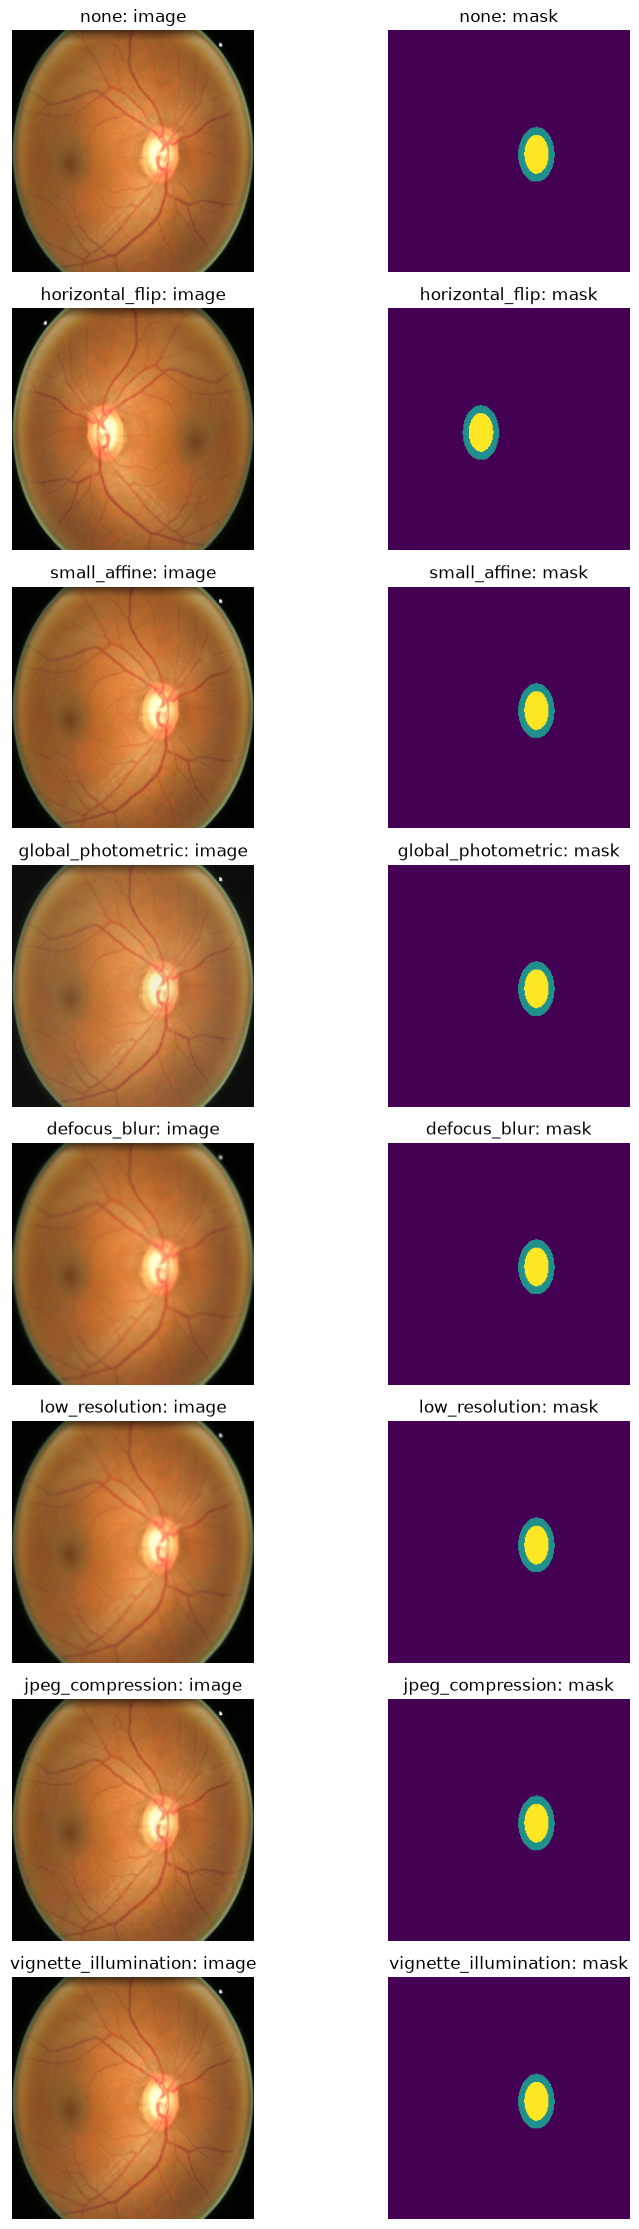

,strategy_name,image_shape,mask_shape,mask_values,source_dataset,split,file_id
0,none,"(3, 256, 256)","(256, 256)","[0, 1, 2]",ORIGA,train,001
1,horizontal_flip,"(3, 256, 256)","(256, 256)","[0, 1, 2]",ORIGA,train,001
2,small_affine,"(3, 256, 256)","(256, 256)","[0, 1, 2]",ORIGA,train,001
3,global_photometric,"(3, 256, 256)","(256, 256)","[0, 1, 2]",ORIGA,train,001
4,defocus_blur,"(3, 256, 256)","(256, 256)","[0, 1, 2]",ORIGA,train,001
5,low_resolution,"(3, 256, 256)","(256, 256)","[0, 1, 2]",ORIGA,train,001
6,jpeg_compression,"(3, 256, 256)","(256, 256)","[0, 1, 2]",ORIGA,train,001
7,vignette_illumination,"(3, 256, 256)","(256, 256)","[0, 1, 2]",ORIGA,train,001


In [8]:
# 05.08 — Augmentation visual QA

visual_strategy_names = ["none", *SCREEN_STRATEGIES]
visual_samples = {}

for strategy_name in visual_strategy_names:
    seed_everything(SEED, deterministic=False, cudnn_benchmark=True)

    dataset = make_segmentation_dataset(
        manifest_path=MANIFEST_PATH,
        split="train",
        image_size=IMAGE_SIZE,
        validate_paths=True,
        validate_masks=False,
        transform=build_online_augmentation_preset(strategy_name),
    )

    # Draw a few times so stochastic image-only transforms are likely to be visible.
    sample = dataset[0]
    for _ in range(4):
        sample = dataset[0]

    visual_samples[strategy_name] = sample

fig, axes = plt.subplots(
    nrows=len(visual_strategy_names),
    ncols=2,
    figsize=(9, 2.8 * len(visual_strategy_names)),
)

if len(visual_strategy_names) == 1:
    axes = np.array([axes])

for row_index, strategy_name in enumerate(visual_strategy_names):
    sample = visual_samples[strategy_name]

    image = sample["image"].detach().cpu().permute(1, 2, 0).numpy()
    mask = sample["mask"].detach().cpu().numpy()

    axes[row_index, 0].imshow(image)
    axes[row_index, 0].set_title(f"{strategy_name}: image")
    axes[row_index, 0].axis("off")

    axes[row_index, 1].imshow(mask, vmin=0, vmax=2)
    axes[row_index, 1].set_title(f"{strategy_name}: mask")
    axes[row_index, 1].axis("off")

plt.tight_layout()
plt.show()

visual_check = pd.DataFrame(
    [
        {
            "strategy_name": strategy_name,
            "image_shape": tuple(sample["image"].shape),
            "mask_shape": tuple(sample["mask"].shape),
            "mask_values": sorted(int(value) for value in torch.unique(sample["mask"]).tolist()),
            "source_dataset": sample.get("source_dataset"),
            "split": sample.get("split"),
            "file_id": sample.get("file_id"),
        }
        for strategy_name, sample in visual_samples.items()
    ]
)

display(visual_check)

for mask_values in visual_check["mask_values"]:
    assert set(mask_values).issubset({0, 1, 2}), f"Unexpected mask values after augmentation: {mask_values}"

## 05.09 — Augmented dataloader and mask-integrity smoke test

In [9]:
# 05.09 — Augmented dataloader and mask-integrity smoke test

qa_loaders_by_strategy = {}
qa_batches_by_strategy = {}
batch_checks = []

for strategy_name in ["none", *SCREEN_STRATEGIES]:
    seed_everything(SEED, deterministic=False, cudnn_benchmark=True)

    loaders = make_segmentation_dataloaders(
        manifest_path=MANIFEST_PATH,
        batch_size=QA_BATCH_SIZE,
        image_size=IMAGE_SIZE,
        num_workers=0,
        validate_paths=True,
        validate_masks=False,
        train_transform=build_online_augmentation_preset(strategy_name),
        val_transform=None,
        test_transform=None,
        pin_memory=False,
    )

    assert loaders.train is not None
    qa_loaders_by_strategy[strategy_name] = loaders

    batch = next(iter(loaders.train))
    qa_batches_by_strategy[strategy_name] = batch

    images, masks = extract_images_and_masks(batch)
    mask_values = sorted(int(value) for value in torch.unique(masks).tolist())

    batch_checks.append(
        {
            "strategy_name": strategy_name,
            "image_shape": tuple(images.shape),
            "mask_shape": tuple(masks.shape),
            "image_min": float(images.min()),
            "image_max": float(images.max()),
            "image_mean": float(images.mean()),
            "mask_values": mask_values,
            "mask_values_valid": set(mask_values).issubset({0, 1, 2}),
            "train_rows": len(loaders.train.dataset),
            "val_rows": len(loaders.val.dataset) if loaders.val is not None else 0,
            "test_rows": len(loaders.test.dataset) if loaders.test is not None else 0,
        }
    )

batch_check_df = pd.DataFrame(batch_checks)
display(batch_check_df)

assert batch_check_df["mask_values_valid"].all(), "At least one strategy produced invalid mask labels."

for row in batch_checks:
    assert row["image_shape"] == (QA_BATCH_SIZE, 3, IMAGE_SIZE[1], IMAGE_SIZE[0])
    assert row["mask_shape"] == (QA_BATCH_SIZE, IMAGE_SIZE[1], IMAGE_SIZE[0])
    assert 0.0 <= row["image_min"] <= 1.0
    assert 0.0 <= row["image_max"] <= 1.0

,strategy_name,image_shape,mask_shape,image_min,image_max,image_mean,mask_values,mask_values_valid,train_rows,val_rows,test_rows
0,none,"(2, 3, 256, 256)","(2, 256, 256)",0.0,0.980392,0.184854,"[0, 1, 2]",True,1911,725,722
1,horizontal_flip,"(2, 3, 256, 256)","(2, 256, 256)",0.0,0.980392,0.184854,"[0, 1, 2]",True,1911,725,722
2,small_affine,"(2, 3, 256, 256)","(2, 256, 256)",0.0,0.980236,0.189130,"[0, 1, 2]",True,1911,725,722
3,global_photometric,"(2, 3, 256, 256)","(2, 256, 256)",0.0,1.000000,0.185365,"[0, 1, 2]",True,1911,725,722
4,defocus_blur,"(2, 3, 256, 256)","(2, 256, 256)",0.0,0.977408,0.184882,"[0, 1, 2]",True,1911,725,722
5,low_resolution,"(2, 3, 256, 256)","(2, 256, 256)",0.0,0.977824,0.184857,"[0, 1, 2]",True,1911,725,722
6,jpeg_compression,"(2, 3, 256, 256)","(2, 256, 256)",0.0,1.000000,0.186103,"[0, 1, 2]",True,1911,725,722
7,vignette_illumination,"(2, 3, 256, 256)","(2, 256, 256)",0.0,0.980392,0.169463,"[0, 1, 2]",True,1911,725,722


## 05.10 — Model/loss smoke test across selected neural nets

In [10]:
# 05.10 — Model/loss smoke test across selected neural nets

smoke_rows = []

for _, model_row in selected_model_baselines.iterrows():
    model_name = model_row["model"]
    encoder_name = model_row["encoder"]
    encoder_weights = normalize_optional_value(model_row["encoder_weights"])

    seed_everything(SEED, deterministic=False, cudnn_benchmark=True)

    model = build_model(
        model_name=model_name,
        in_channels=IN_CHANNELS,
        classes=CLASSES,
        encoder_name=encoder_name,
        encoder_weights=encoder_weights,
    )

    criterion = DiceCELoss()
    model = model.to(DEVICE)
    model.eval()

    model_parameter_count = sum(parameter.numel() for parameter in model.parameters())
    trainable_parameter_count = sum(
        parameter.numel() for parameter in model.parameters() if parameter.requires_grad
    )

    with torch.no_grad():
        for strategy_name, batch in qa_batches_by_strategy.items():
            images, masks = extract_images_and_masks(batch)
            images = images.to(DEVICE).float()
            masks = masks.to(DEVICE).long()

            logits = model_forward(model, images)
            loss = criterion(logits, masks)

            smoke_rows.append(
                {
                    "model": model_name,
                    "encoder": encoder_name,
                    "encoder_weights": encoder_weights,
                    "strategy_name": strategy_name,
                    "logits_shape": tuple(logits.shape),
                    "loss": float(loss.detach().cpu()),
                    "loss_is_finite": bool(torch.isfinite(loss).detach().cpu()),
                    "model_parameters": model_parameter_count,
                    "trainable_parameters": trainable_parameter_count,
                }
            )

    del model, criterion

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

smoke_test_df = pd.DataFrame(smoke_rows)
display(smoke_test_df)

assert smoke_test_df["loss_is_finite"].all(), "At least one smoke-test loss was non-finite."

expected_logits_shape = (QA_BATCH_SIZE, CLASSES, IMAGE_SIZE[1], IMAGE_SIZE[0])
for logits_shape in smoke_test_df["logits_shape"]:
    assert logits_shape == expected_logits_shape, f"Unexpected logits shape: {logits_shape}"

,model,encoder,encoder_weights,strategy_name,logits_shape,loss,loss_is_finite,model_parameters,trainable_parameters
0,unetplusplus,resnet18,None,none,"(2, 3, 256, 256)",2.044991,True,15970739,15970739
1,unetplusplus,resnet18,None,horizontal_flip,"(2, 3, 256, 256)",2.044538,True,15970739,15970739
2,unetplusplus,resnet18,None,small_affine,"(2, 3, 256, 256)",2.042502,True,15970739,15970739
3,unetplusplus,resnet18,None,global_photometric,"(2, 3, 256, 256)",2.044232,True,15970739,15970739
4,unetplusplus,resnet18,None,defocus_blur,"(2, 3, 256, 256)",2.043409,True,15970739,15970739
5,unetplusplus,resnet18,None,low_resolution,"(2, 3, 256, 256)",2.043642,True,15970739,15970739
6,unetplusplus,resnet18,None,jpeg_compression,"(2, 3, 256, 256)",2.045390,True,15970739,15970739
7,unetplusplus,resnet18,None,vignette_illumination,"(2, 3, 256, 256)",2.034048,True,15970739,15970739
8,unet,resnet18,None,none,"(2, 3, 256, 256)",1.919801,True,14328499,14328499
9,unet,resnet18,None,horizontal_flip,"(2, 3, 256, 256)",1.917040,True,14328499,14328499


## 05.11 — Independent augmentation training plan

In [11]:
# 05.11 — Independent augmentation training plan

INDEPENDENT_HISTORY_PATH = TRAINING_REPORTS_DIR / "online_augmentation_independent_training_history.csv"
INDEPENDENT_METADATA_PATH = TRAINING_REPORTS_DIR / "online_augmentation_independent_run_metadata.csv"
INDEPENDENT_SUMMARY_PATH = TRAINING_REPORTS_DIR / "online_augmentation_independent_summary.csv"
INDEPENDENT_WINNERS_PATH = TRAINING_REPORTS_DIR / "online_augmentation_independent_winners.csv"
INDEPENDENT_PLAN_PATH = TRAINING_REPORTS_DIR / "online_augmentation_independent_training_plan.csv"

RUN_INDEPENDENT_SCREEN = True
MAX_INDEPENDENT_RUNS = None

plan_rows = []

for _, model_row in selected_model_baselines.iterrows():
    model_name = model_row["model"]
    encoder_name = model_row["encoder"]
    encoder_weights = normalize_optional_value(model_row["encoder_weights"])

    for strategy_name in SCREEN_STRATEGIES:
        run_name = (
            f"online_aug_{model_name}_{encoder_name}_{strategy_name}_"
            f"{IMAGE_SIZE[0]}px_{EPOCHS_TO_RUN}epoch"
        )

        plan_rows.append(
            {
                "run_name": run_name,
                "model": model_name,
                "encoder": encoder_name,
                "encoder_weights": encoder_weights,
                "augmentation_strategy": strategy_name,
                "image_size": str(IMAGE_SIZE),
                "batch_size": BATCH_SIZE,
                "epochs": EPOCHS_TO_RUN,
                "learning_rate": LEARNING_RATE,
                "weight_decay": WEIGHT_DECAY,
                "num_workers": NUM_WORKERS,
                "device": str(DEVICE),
                "dataset_size_mode": "online augmentation only; original row count unchanged",
            }
        )

independent_training_plan = pd.DataFrame(plan_rows)

if MAX_INDEPENDENT_RUNS is not None:
    independent_training_plan = independent_training_plan.head(MAX_INDEPENDENT_RUNS).copy()

independent_training_plan.to_csv(INDEPENDENT_PLAN_PATH, index=False)

display(independent_training_plan)
print(f"Saved independent training plan: {INDEPENDENT_PLAN_PATH.relative_to(PROJECT_ROOT)}")
print(f"Total independent runs planned: {len(independent_training_plan):,}")

,run_name,model,encoder,encoder_weights,augmentation_strategy,image_size,batch_size,epochs,learning_rate,weight_decay,num_workers,device,dataset_size_mode
0,online_aug_unetplusplus_resnet18_horizontal_fl...,unetplusplus,resnet18,None,horizontal_flip,"(256, 256)",8,5,0.0001,0.0001,2,cuda,online augmentation only; original row count u...
1,online_aug_unetplusplus_resnet18_small_affine_...,unetplusplus,resnet18,None,small_affine,"(256, 256)",8,5,0.0001,0.0001,2,cuda,online augmentation only; original row count u...
2,online_aug_unetplusplus_resnet18_global_photom...,unetplusplus,resnet18,None,global_photometric,"(256, 256)",8,5,0.0001,0.0001,2,cuda,online augmentation only; original row count u...
3,online_aug_unetplusplus_resnet18_defocus_blur_...,unetplusplus,resnet18,None,defocus_blur,"(256, 256)",8,5,0.0001,0.0001,2,cuda,online augmentation only; original row count u...
4,online_aug_unetplusplus_resnet18_low_resolutio...,unetplusplus,resnet18,None,low_resolution,"(256, 256)",8,5,0.0001,0.0001,2,cuda,online augmentation only; original row count u...
5,online_aug_unetplusplus_resnet18_jpeg_compress...,unetplusplus,resnet18,None,jpeg_compression,"(256, 256)",8,5,0.0001,0.0001,2,cuda,online augmentation only; original row count u...
6,online_aug_unetplusplus_resnet18_vignette_illu...,unetplusplus,resnet18,None,vignette_illumination,"(256, 256)",8,5,0.0001,0.0001,2,cuda,online augmentation only; original row count u...
7,online_aug_unet_resnet18_horizontal_flip_256px...,unet,resnet18,None,horizontal_flip,"(256, 256)",8,5,0.0001,0.0001,2,cuda,online augmentation only; original row count u...
8,online_aug_unet_resnet18_small_affine_256px_5e...,unet,resnet18,None,small_affine,"(256, 256)",8,5,0.0001,0.0001,2,cuda,online augmentation only; original row count u...
9,online_aug_unet_resnet18_global_photometric_25...,unet,resnet18,None,global_photometric,"(256, 256)",8,5,0.0001,0.0001,2,cuda,online augmentation only; original row count u...


Saved independent training plan: reports/training/online_augmentation_independent_training_plan.csv
Total independent runs planned: 14


## 05.12 — Independent augmentation run helper

This helper trains one selected model with one atomic online augmentation strategy. Each actual experiment below calls this helper in its own cell.

In [12]:
# 05.12 — Independent augmentation run helper

INDEPENDENT_HISTORY_PATH = TRAINING_REPORTS_DIR / "online_augmentation_independent_training_history.csv"
INDEPENDENT_METADATA_PATH = TRAINING_REPORTS_DIR / "online_augmentation_independent_run_metadata.csv"
INDEPENDENT_SUMMARY_PATH = TRAINING_REPORTS_DIR / "online_augmentation_independent_summary.csv"
INDEPENDENT_WINNERS_PATH = TRAINING_REPORTS_DIR / "online_augmentation_independent_winners.csv"


def _read_csv_or_empty(path: Path) -> pd.DataFrame:
    if path.exists():
        return pd.read_csv(path)

    return pd.DataFrame()


def get_selected_model_config(model_index: int) -> dict[str, object]:
    if model_index < 0 or model_index >= len(selected_model_baselines):
        raise IndexError(
            f"model_index={model_index} is out of range for "
            f"{len(selected_model_baselines)} selected models."
        )

    row = selected_model_baselines.iloc[model_index].to_dict()
    row["encoder_weights"] = normalize_optional_value(row.get("encoder_weights"))

    return row


def get_independent_run_config(model_index: int, strategy_name: str) -> dict[str, object]:
    model_config = get_selected_model_config(model_index)

    matches = independent_training_plan[
        (independent_training_plan["model"] == model_config["model"])
        & (independent_training_plan["encoder"] == model_config["encoder"])
        & (independent_training_plan["augmentation_strategy"] == strategy_name)
    ]

    if matches.empty:
        raise ValueError(
            "No independent training-plan row found for "
            f"model_index={model_index}, strategy_name={strategy_name!r}."
        )

    run_config = matches.iloc[0].to_dict()
    run_config["encoder_weights"] = normalize_optional_value(run_config.get("encoder_weights"))

    return run_config


def run_independent_augmentation_cell(
    model_index: int,
    strategy_name: str,
    overwrite: bool = False,
) -> pd.DataFrame:
    run_config = get_independent_run_config(
        model_index=model_index,
        strategy_name=strategy_name,
    )

    run_name = run_config["run_name"]
    model_name = run_config["model"]
    encoder_name = run_config["encoder"]
    encoder_weights = normalize_optional_value(run_config.get("encoder_weights"))

    existing_history = _read_csv_or_empty(INDEPENDENT_HISTORY_PATH)
    existing_metadata = _read_csv_or_empty(INDEPENDENT_METADATA_PATH)

    if not existing_history.empty and "run_name" in existing_history.columns:
        existing_run = existing_history[existing_history["run_name"] == run_name].copy()

        if not existing_run.empty and not overwrite:
            completed_phases = set(existing_run["phase"].astype(str))
            completed_val_epochs = existing_run.loc[
                existing_run["phase"] == "val",
                "epoch",
            ]

            if {"train", "val"}.issubset(completed_phases) and completed_val_epochs.max() >= EPOCHS_TO_RUN:
                print(f"Run already complete: {run_name}")
                print("Set overwrite=True in this cell to rerun it.")
                display(existing_run.sort_values(["phase", "epoch"]).reset_index(drop=True))
                return existing_run

            print(f"Existing partial run found and will be replaced: {run_name}")

    if not existing_history.empty and "run_name" in existing_history.columns:
        existing_history = existing_history[existing_history["run_name"] != run_name].copy()

    if not existing_metadata.empty and "run_name" in existing_metadata.columns:
        existing_metadata = existing_metadata[existing_metadata["run_name"] != run_name].copy()

    seed_everything(SEED, deterministic=False, cudnn_benchmark=True)

    loaders = make_segmentation_dataloaders(
        manifest_path=MANIFEST_PATH,
        batch_size=BATCH_SIZE,
        image_size=IMAGE_SIZE,
        num_workers=NUM_WORKERS,
        validate_paths=True,
        validate_masks=False,
        train_transform=build_online_augmentation_preset(strategy_name),
        val_transform=None,
        test_transform=None,
        pin_memory=PIN_MEMORY,
    )

    assert loaders.train is not None, f"Missing train loader for {run_name}"
    assert loaders.val is not None, f"Missing validation loader for {run_name}"

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    model = build_model(
        model_name=model_name,
        in_channels=IN_CHANNELS,
        classes=CLASSES,
        encoder_name=encoder_name,
        encoder_weights=encoder_weights,
    )

    criterion = DiceCELoss()
    optimizer = AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    print()
    print("#" * 100)
    print(f"Run name: {run_name}")
    print(f"Selected model index: {model_index}")
    print(f"Model: {model_name} / {encoder_name}")
    print(f"Augmentation strategy: {strategy_name}")
    print("#" * 100)

    run_start = time.perf_counter()

    history = fit_model_with_progress(
        model=model,
        train_loader=loaders.train,
        val_loader=loaders.val,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE,
        epochs=EPOCHS_TO_RUN,
        run_name=run_name,
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        leave_progress=True,
    )

    run_elapsed_seconds = time.perf_counter() - run_start
    history_rows = history_to_dicts(history)

    for row in history_rows:
        row.update(
            {
                "run_name": run_name,
                "augmentation_strategy": strategy_name,
                "experiment_stage": "independent_strategy_screen",
                "notebook": "05_online_augmentation_ablation",
                "model": model_name,
                "encoder": encoder_name,
                "encoder_weights": encoder_weights,
                "image_size": str(IMAGE_SIZE),
                "batch_size": BATCH_SIZE,
                "learning_rate": LEARNING_RATE,
                "weight_decay": WEIGHT_DECAY,
                "seed": SEED,
                "device": str(DEVICE),
                "mean_foreground_dice": (row["disc_dice"] + row["cup_dice"]) / 2.0,
            }
        )

    run_history = pd.DataFrame(history_rows)

    peak_gpu_memory_mb = np.nan
    if DEVICE.type == "cuda":
        peak_gpu_memory_mb = torch.cuda.max_memory_allocated() / (1024**2)

    run_metadata = pd.DataFrame(
        [
            {
                "run_name": run_name,
                "augmentation_strategy": strategy_name,
                "model": model_name,
                "encoder": encoder_name,
                "encoder_weights": encoder_weights,
                "run_elapsed_minutes": run_elapsed_seconds / 60.0,
                "history_elapsed_minutes": sum(result.elapsed_seconds for result in history) / 60.0,
                "peak_gpu_memory_mb": peak_gpu_memory_mb,
            }
        ]
    )

    updated_history = pd.concat([existing_history, run_history], ignore_index=True, sort=False)
    updated_metadata = pd.concat([existing_metadata, run_metadata], ignore_index=True, sort=False)

    updated_history.to_csv(INDEPENDENT_HISTORY_PATH, index=False)
    updated_metadata.to_csv(INDEPENDENT_METADATA_PATH, index=False)

    print(f"Saved independent history: {INDEPENDENT_HISTORY_PATH.relative_to(PROJECT_ROOT)}")
    print(f"Saved independent metadata: {INDEPENDENT_METADATA_PATH.relative_to(PROJECT_ROOT)}")

    val_history = run_history[run_history["phase"] == "val"].copy()
    val_history = val_history.sort_values("mean_foreground_dice", ascending=False)

    print()
    print("Best validation epoch for this run by mean foreground Dice:")
    display(
        val_history[
            [
                "epoch",
                "loss",
                "disc_dice",
                "cup_dice",
                "mean_foreground_dice",
                "cdr_mae",
                "elapsed_seconds",
            ]
        ].head(1)
    )

    display(run_metadata)

    del model, optimizer, criterion

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return run_history


def show_independent_run_completion() -> pd.DataFrame:
    history = _read_csv_or_empty(INDEPENDENT_HISTORY_PATH)

    completion = independent_training_plan.copy()
    completion["completed_val_epochs"] = 0
    completion["run_complete"] = False

    if not history.empty and {"run_name", "phase", "epoch"}.issubset(history.columns):
        val_epochs = (
            history[history["phase"] == "val"]
            .groupby("run_name")["epoch"]
            .max()
            .rename("completed_val_epochs")
            .reset_index()
        )

        completion = completion.drop(columns=["completed_val_epochs"]).merge(
            val_epochs,
            on="run_name",
            how="left",
        )

        completion["completed_val_epochs"] = completion["completed_val_epochs"].fillna(0).astype(int)
        completion["run_complete"] = completion["completed_val_epochs"] >= EPOCHS_TO_RUN

    display(
        completion[
            [
                "model",
                "encoder",
                "augmentation_strategy",
                "completed_val_epochs",
                "run_complete",
                "run_name",
            ]
        ]
    )

    return completion


print("Independent augmentation helper is ready.")
print("Each model/augmentation run below is now a separate runnable cell.")
show_independent_run_completion()

Independent augmentation helper is ready.
Each model/augmentation run below is now a separate runnable cell.


,model,encoder,augmentation_strategy,completed_val_epochs,run_complete,run_name
0,unetplusplus,resnet18,horizontal_flip,5,True,online_aug_unetplusplus_resnet18_horizontal_fl...
1,unetplusplus,resnet18,small_affine,5,True,online_aug_unetplusplus_resnet18_small_affine_...
2,unetplusplus,resnet18,global_photometric,5,True,online_aug_unetplusplus_resnet18_global_photom...
3,unetplusplus,resnet18,defocus_blur,5,True,online_aug_unetplusplus_resnet18_defocus_blur_...
4,unetplusplus,resnet18,low_resolution,5,True,online_aug_unetplusplus_resnet18_low_resolutio...
5,unetplusplus,resnet18,jpeg_compression,5,True,online_aug_unetplusplus_resnet18_jpeg_compress...
6,unetplusplus,resnet18,vignette_illumination,5,True,online_aug_unetplusplus_resnet18_vignette_illu...
7,unet,resnet18,horizontal_flip,5,True,online_aug_unet_resnet18_horizontal_flip_256px...
8,unet,resnet18,small_affine,5,True,online_aug_unet_resnet18_small_affine_256px_5e...
9,unet,resnet18,global_photometric,5,True,online_aug_unet_resnet18_global_photometric_25...


,run_name,model,encoder,encoder_weights,augmentation_strategy,image_size,batch_size,epochs,learning_rate,weight_decay,num_workers,device,dataset_size_mode,run_complete,completed_val_epochs
0,online_aug_unetplusplus_resnet18_horizontal_fl...,unetplusplus,resnet18,None,horizontal_flip,"(256, 256)",8,5,0.0001,0.0001,2,cuda,online augmentation only; original row count u...,True,5
1,online_aug_unetplusplus_resnet18_small_affine_...,unetplusplus,resnet18,None,small_affine,"(256, 256)",8,5,0.0001,0.0001,2,cuda,online augmentation only; original row count u...,True,5
2,online_aug_unetplusplus_resnet18_global_photom...,unetplusplus,resnet18,None,global_photometric,"(256, 256)",8,5,0.0001,0.0001,2,cuda,online augmentation only; original row count u...,True,5
3,online_aug_unetplusplus_resnet18_defocus_blur_...,unetplusplus,resnet18,None,defocus_blur,"(256, 256)",8,5,0.0001,0.0001,2,cuda,online augmentation only; original row count u...,True,5
4,online_aug_unetplusplus_resnet18_low_resolutio...,unetplusplus,resnet18,None,low_resolution,"(256, 256)",8,5,0.0001,0.0001,2,cuda,online augmentation only; original row count u...,True,5
5,online_aug_unetplusplus_resnet18_jpeg_compress...,unetplusplus,resnet18,None,jpeg_compression,"(256, 256)",8,5,0.0001,0.0001,2,cuda,online augmentation only; original row count u...,True,5
6,online_aug_unetplusplus_resnet18_vignette_illu...,unetplusplus,resnet18,None,vignette_illumination,"(256, 256)",8,5,0.0001,0.0001,2,cuda,online augmentation only; original row count u...,True,5
7,online_aug_unet_resnet18_horizontal_flip_256px...,unet,resnet18,None,horizontal_flip,"(256, 256)",8,5,0.0001,0.0001,2,cuda,online augmentation only; original row count u...,True,5
8,online_aug_unet_resnet18_small_affine_256px_5e...,unet,resnet18,None,small_affine,"(256, 256)",8,5,0.0001,0.0001,2,cuda,online augmentation only; original row count u...,True,5
9,online_aug_unet_resnet18_global_photometric_25...,unet,resnet18,None,global_photometric,"(256, 256)",8,5,0.0001,0.0001,2,cuda,online augmentation only; original row count u...,True,5


## 05.13 — Run model 1: horizontal flip

In [13]:
# 05.13 — Run model 1: horizontal_flip

run_independent_augmentation_cell(
    model_index=0,
    strategy_name="horizontal_flip",
    overwrite=False,
)

Run already complete: online_aug_unetplusplus_resnet18_horizontal_flip_256px_5epoch
Set overwrite=True in this cell to rerun it.


,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches,run_name,augmentation_strategy,experiment_stage,notebook,model,encoder,encoder_weights,image_size,batch_size,learning_rate,weight_decay,seed,device,mean_foreground_dice
0,train,1,1.381355,0.383529,0.348795,0.423514,1911,239,169.444315,NaN,online_aug_unetplusplus_resnet18_horizontal_fl...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.366162
1,train,2,0.655530,0.718677,0.640774,0.193515,1911,239,145.763998,NaN,online_aug_unetplusplus_resnet18_horizontal_fl...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.679725
2,train,3,0.343366,0.770446,0.686334,0.112216,1911,239,146.543052,NaN,online_aug_unetplusplus_resnet18_horizontal_fl...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.728390
3,train,4,0.217764,0.805664,0.713568,0.099547,1911,239,146.000887,NaN,online_aug_unetplusplus_resnet18_horizontal_fl...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.759616
4,train,5,0.174471,0.829465,0.734938,0.090934,1911,239,145.729178,NaN,online_aug_unetplusplus_resnet18_horizontal_fl...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.782202
5,val,1,0.907215,0.584778,0.566899,0.328862,725,91,51.060964,NaN,online_aug_unetplusplus_resnet18_horizontal_fl...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.575838
6,val,2,0.488407,0.775009,0.741347,0.086808,725,91,41.384309,NaN,online_aug_unetplusplus_resnet18_horizontal_fl...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.758178
7,val,3,0.262400,0.774286,0.733223,0.081260,725,91,41.320535,NaN,online_aug_unetplusplus_resnet18_horizontal_fl...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.753755
8,val,4,0.186249,0.826365,0.765234,0.071271,725,91,41.122896,NaN,online_aug_unetplusplus_resnet18_horizontal_fl...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.795800
9,val,5,0.163411,0.829407,0.783404,0.071367,725,91,40.629919,NaN,online_aug_unetplusplus_resnet18_horizontal_fl...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.806406


,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches,run_name,augmentation_strategy,experiment_stage,notebook,model,encoder,encoder_weights,image_size,batch_size,learning_rate,weight_decay,seed,device,mean_foreground_dice
0,train,1,1.381355,0.383529,0.348795,0.423514,1911,239,169.444315,NaN,online_aug_unetplusplus_resnet18_horizontal_fl...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.366162
1,val,1,0.907215,0.584778,0.566899,0.328862,725,91,51.060964,NaN,online_aug_unetplusplus_resnet18_horizontal_fl...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.575838
2,train,2,0.655530,0.718677,0.640774,0.193515,1911,239,145.763998,NaN,online_aug_unetplusplus_resnet18_horizontal_fl...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.679725
3,val,2,0.488407,0.775009,0.741347,0.086808,725,91,41.384309,NaN,online_aug_unetplusplus_resnet18_horizontal_fl...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.758178
4,train,3,0.343366,0.770446,0.686334,0.112216,1911,239,146.543052,NaN,online_aug_unetplusplus_resnet18_horizontal_fl...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.728390
5,val,3,0.262400,0.774286,0.733223,0.081260,725,91,41.320535,NaN,online_aug_unetplusplus_resnet18_horizontal_fl...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.753755
6,train,4,0.217764,0.805664,0.713568,0.099547,1911,239,146.000887,NaN,online_aug_unetplusplus_resnet18_horizontal_fl...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.759616
7,val,4,0.186249,0.826365,0.765234,0.071271,725,91,41.122896,NaN,online_aug_unetplusplus_resnet18_horizontal_fl...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.795800
8,train,5,0.174471,0.829465,0.734938,0.090934,1911,239,145.729178,NaN,online_aug_unetplusplus_resnet18_horizontal_fl...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.782202
9,val,5,0.163411,0.829407,0.783404,0.071367,725,91,40.629919,NaN,online_aug_unetplusplus_resnet18_horizontal_fl...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.806406


## 05.14 — Run model 1: small affine

In [14]:
# 05.14 — Run model 1: small_affine

run_independent_augmentation_cell(
    model_index=0,
    strategy_name="small_affine",
    overwrite=False,
)

Run already complete: online_aug_unetplusplus_resnet18_small_affine_256px_5epoch
Set overwrite=True in this cell to rerun it.


,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches,run_name,augmentation_strategy,experiment_stage,notebook,model,encoder,encoder_weights,image_size,batch_size,learning_rate,weight_decay,seed,device,mean_foreground_dice
0,train,1,1.373407,0.405102,0.309186,0.419844,1911,239,157.711938,NaN,online_aug_unetplusplus_resnet18_small_affine_...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.357144
1,train,2,0.676253,0.716024,0.634550,0.187674,1911,239,155.620840,NaN,online_aug_unetplusplus_resnet18_small_affine_...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.675287
2,train,3,0.409953,0.759729,0.682720,0.114395,1911,239,155.023257,NaN,online_aug_unetplusplus_resnet18_small_affine_...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.721224
3,train,4,0.250878,0.797230,0.709324,0.104083,1911,239,154.548384,NaN,online_aug_unetplusplus_resnet18_small_affine_...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.753277
4,train,5,0.193634,0.816609,0.722892,0.096102,1911,239,155.136074,NaN,online_aug_unetplusplus_resnet18_small_affine_...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.769751
5,val,1,0.899081,0.583138,0.568484,0.324293,725,91,42.878940,NaN,online_aug_unetplusplus_resnet18_small_affine_...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.575811
6,val,2,0.542762,0.763653,0.707499,0.102042,725,91,42.239280,NaN,online_aug_unetplusplus_resnet18_small_affine_...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.735576
7,val,3,0.361375,0.696315,0.664412,0.100153,725,91,42.335027,NaN,online_aug_unetplusplus_resnet18_small_affine_...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.680364
8,val,4,0.201442,0.825090,0.765481,0.083849,725,91,42.767348,NaN,online_aug_unetplusplus_resnet18_small_affine_...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.795285
9,val,5,0.167172,0.841416,0.781706,0.068719,725,91,42.768027,NaN,online_aug_unetplusplus_resnet18_small_affine_...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.811561


,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches,run_name,augmentation_strategy,experiment_stage,notebook,model,encoder,encoder_weights,image_size,batch_size,learning_rate,weight_decay,seed,device,mean_foreground_dice
10,train,1,1.373407,0.405102,0.309186,0.419844,1911,239,157.711938,NaN,online_aug_unetplusplus_resnet18_small_affine_...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.357144
11,val,1,0.899081,0.583138,0.568484,0.324293,725,91,42.878940,NaN,online_aug_unetplusplus_resnet18_small_affine_...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.575811
12,train,2,0.676253,0.716024,0.634550,0.187674,1911,239,155.620840,NaN,online_aug_unetplusplus_resnet18_small_affine_...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.675287
13,val,2,0.542762,0.763653,0.707499,0.102042,725,91,42.239280,NaN,online_aug_unetplusplus_resnet18_small_affine_...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.735576
14,train,3,0.409953,0.759729,0.682720,0.114395,1911,239,155.023257,NaN,online_aug_unetplusplus_resnet18_small_affine_...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.721224
15,val,3,0.361375,0.696315,0.664412,0.100153,725,91,42.335027,NaN,online_aug_unetplusplus_resnet18_small_affine_...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.680364
16,train,4,0.250878,0.797230,0.709324,0.104083,1911,239,154.548384,NaN,online_aug_unetplusplus_resnet18_small_affine_...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.753277
17,val,4,0.201442,0.825090,0.765481,0.083849,725,91,42.767348,NaN,online_aug_unetplusplus_resnet18_small_affine_...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.795285
18,train,5,0.193634,0.816609,0.722892,0.096102,1911,239,155.136074,NaN,online_aug_unetplusplus_resnet18_small_affine_...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.769751
19,val,5,0.167172,0.841416,0.781706,0.068719,725,91,42.768027,NaN,online_aug_unetplusplus_resnet18_small_affine_...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.811561


## 05.15 — Run model 1: global photometric

In [15]:
# 05.15 — Run model 1: global_photometric

run_independent_augmentation_cell(
    model_index=0,
    strategy_name="global_photometric",
    overwrite=False,
)

Run already complete: online_aug_unetplusplus_resnet18_global_photometric_256px_5epoch
Set overwrite=True in this cell to rerun it.


,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches,run_name,augmentation_strategy,experiment_stage,notebook,model,encoder,encoder_weights,image_size,batch_size,learning_rate,weight_decay,seed,device,mean_foreground_dice
0,train,1,1.392182,0.384700,0.304274,0.429620,1911,239,170.956766,NaN,online_aug_unetplusplus_resnet18_global_photom...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.344487
1,train,2,0.716546,0.713039,0.640043,0.165652,1911,239,151.571944,NaN,online_aug_unetplusplus_resnet18_global_photom...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.676541
2,train,3,0.409297,0.760784,0.674945,0.115629,1911,239,155.310263,NaN,online_aug_unetplusplus_resnet18_global_photom...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.717865
3,train,4,0.242154,0.792797,0.711446,0.100862,1911,239,151.164375,NaN,online_aug_unetplusplus_resnet18_global_photom...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.752122
4,train,5,0.181915,0.824117,0.734426,0.089066,1911,239,155.507709,NaN,online_aug_unetplusplus_resnet18_global_photom...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.779272
5,val,1,0.916302,0.671235,0.651667,0.330643,725,91,49.473155,NaN,online_aug_unetplusplus_resnet18_global_photom...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.661451
6,val,2,0.594801,0.756775,0.640908,0.136437,725,91,41.715890,NaN,online_aug_unetplusplus_resnet18_global_photom...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.698842
7,val,3,0.303812,0.758664,0.741374,0.083934,725,91,41.961613,NaN,online_aug_unetplusplus_resnet18_global_photom...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.750019
8,val,4,0.201436,0.813697,0.759505,0.074040,725,91,41.989145,NaN,online_aug_unetplusplus_resnet18_global_photom...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.786601
9,val,5,0.176800,0.816412,0.773365,0.082657,725,91,42.491882,NaN,online_aug_unetplusplus_resnet18_global_photom...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.794888


,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches,run_name,augmentation_strategy,experiment_stage,notebook,model,encoder,encoder_weights,image_size,batch_size,learning_rate,weight_decay,seed,device,mean_foreground_dice
20,train,1,1.392182,0.384700,0.304274,0.429620,1911,239,170.956766,NaN,online_aug_unetplusplus_resnet18_global_photom...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.344487
21,val,1,0.916302,0.671235,0.651667,0.330643,725,91,49.473155,NaN,online_aug_unetplusplus_resnet18_global_photom...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.661451
22,train,2,0.716546,0.713039,0.640043,0.165652,1911,239,151.571944,NaN,online_aug_unetplusplus_resnet18_global_photom...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.676541
23,val,2,0.594801,0.756775,0.640908,0.136437,725,91,41.715890,NaN,online_aug_unetplusplus_resnet18_global_photom...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.698842
24,train,3,0.409297,0.760784,0.674945,0.115629,1911,239,155.310263,NaN,online_aug_unetplusplus_resnet18_global_photom...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.717865
25,val,3,0.303812,0.758664,0.741374,0.083934,725,91,41.961613,NaN,online_aug_unetplusplus_resnet18_global_photom...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.750019
26,train,4,0.242154,0.792797,0.711446,0.100862,1911,239,151.164375,NaN,online_aug_unetplusplus_resnet18_global_photom...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.752122
27,val,4,0.201436,0.813697,0.759505,0.074040,725,91,41.989145,NaN,online_aug_unetplusplus_resnet18_global_photom...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.786601
28,train,5,0.181915,0.824117,0.734426,0.089066,1911,239,155.507709,NaN,online_aug_unetplusplus_resnet18_global_photom...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.779272
29,val,5,0.176800,0.816412,0.773365,0.082657,725,91,42.491882,NaN,online_aug_unetplusplus_resnet18_global_photom...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.794888


## 05.16 — Run model 1: defocus blur

In [16]:
# 05.16 — Run model 1: defocus_blur

run_independent_augmentation_cell(
    model_index=0,
    strategy_name="defocus_blur",
    overwrite=False,
)

Run already complete: online_aug_unetplusplus_resnet18_defocus_blur_256px_5epoch
Set overwrite=True in this cell to rerun it.


,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches,run_name,augmentation_strategy,experiment_stage,notebook,model,encoder,encoder_weights,image_size,batch_size,learning_rate,weight_decay,seed,device,mean_foreground_dice
0,train,1,1.378195,0.412937,0.324591,0.407116,1911,239,93.391308,NaN,online_aug_unetplusplus_resnet18_defocus_blur_...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.368764
1,train,2,0.688747,0.727426,0.643239,0.196629,1911,239,80.302599,NaN,online_aug_unetplusplus_resnet18_defocus_blur_...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.685332
2,train,3,0.383354,0.770558,0.678024,0.114798,1911,239,80.325865,NaN,online_aug_unetplusplus_resnet18_defocus_blur_...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.724291
3,train,4,0.238187,0.805215,0.714493,0.098681,1911,239,81.141104,NaN,online_aug_unetplusplus_resnet18_defocus_blur_...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.759854
4,train,5,0.184204,0.827850,0.731518,0.091558,1911,239,79.579199,NaN,online_aug_unetplusplus_resnet18_defocus_blur_...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.779684
5,val,1,0.907289,0.625982,0.616208,0.309400,725,91,30.069611,NaN,online_aug_unetplusplus_resnet18_defocus_blur_...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.621095
6,val,2,0.526213,0.743740,0.709748,0.101003,725,91,23.811281,NaN,online_aug_unetplusplus_resnet18_defocus_blur_...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.726744
7,val,3,0.285092,0.802474,0.751166,0.073665,725,91,24.046971,NaN,online_aug_unetplusplus_resnet18_defocus_blur_...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.776820
8,val,4,0.199246,0.822150,0.769758,0.078087,725,91,24.109986,NaN,online_aug_unetplusplus_resnet18_defocus_blur_...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.795954
9,val,5,0.171293,0.828851,0.777298,0.075000,725,91,23.999792,NaN,online_aug_unetplusplus_resnet18_defocus_blur_...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.803074


,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches,run_name,augmentation_strategy,experiment_stage,notebook,model,encoder,encoder_weights,image_size,batch_size,learning_rate,weight_decay,seed,device,mean_foreground_dice
30,train,1,1.378195,0.412937,0.324591,0.407116,1911,239,93.391308,NaN,online_aug_unetplusplus_resnet18_defocus_blur_...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.368764
31,val,1,0.907289,0.625982,0.616208,0.309400,725,91,30.069611,NaN,online_aug_unetplusplus_resnet18_defocus_blur_...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.621095
32,train,2,0.688747,0.727426,0.643239,0.196629,1911,239,80.302599,NaN,online_aug_unetplusplus_resnet18_defocus_blur_...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.685332
33,val,2,0.526213,0.743740,0.709748,0.101003,725,91,23.811281,NaN,online_aug_unetplusplus_resnet18_defocus_blur_...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.726744
34,train,3,0.383354,0.770558,0.678024,0.114798,1911,239,80.325865,NaN,online_aug_unetplusplus_resnet18_defocus_blur_...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.724291
35,val,3,0.285092,0.802474,0.751166,0.073665,725,91,24.046971,NaN,online_aug_unetplusplus_resnet18_defocus_blur_...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.776820
36,train,4,0.238187,0.805215,0.714493,0.098681,1911,239,81.141104,NaN,online_aug_unetplusplus_resnet18_defocus_blur_...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.759854
37,val,4,0.199246,0.822150,0.769758,0.078087,725,91,24.109986,NaN,online_aug_unetplusplus_resnet18_defocus_blur_...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.795954
38,train,5,0.184204,0.827850,0.731518,0.091558,1911,239,79.579199,NaN,online_aug_unetplusplus_resnet18_defocus_blur_...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.779684
39,val,5,0.171293,0.828851,0.777298,0.075000,725,91,23.999792,NaN,online_aug_unetplusplus_resnet18_defocus_blur_...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.803074


## 05.17 — Run model 1: low resolution

In [17]:
# 05.17 — Run model 1: low_resolution

run_independent_augmentation_cell(
    model_index=0,
    strategy_name="low_resolution",
    overwrite=False,
)

Run already complete: online_aug_unetplusplus_resnet18_low_resolution_256px_5epoch
Set overwrite=True in this cell to rerun it.


,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches,run_name,augmentation_strategy,experiment_stage,notebook,model,encoder,encoder_weights,image_size,batch_size,learning_rate,weight_decay,seed,device,mean_foreground_dice
0,train,1,1.383781,0.397415,0.317981,0.429693,1911,239,81.456821,NaN,online_aug_unetplusplus_resnet18_low_resolutio...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.357698
1,train,2,0.683234,0.718529,0.632766,0.221558,1911,239,81.156215,NaN,online_aug_unetplusplus_resnet18_low_resolutio...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.675648
2,train,3,0.401804,0.764120,0.677509,0.118455,1911,239,80.545573,NaN,online_aug_unetplusplus_resnet18_low_resolutio...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.720814
3,train,4,0.242806,0.802576,0.714080,0.099006,1911,239,80.617591,NaN,online_aug_unetplusplus_resnet18_low_resolutio...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.758328
4,train,5,0.184385,0.825857,0.731319,0.093750,1911,239,80.639312,NaN,online_aug_unetplusplus_resnet18_low_resolutio...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.778588
5,val,1,0.900886,0.623429,0.640361,0.323088,725,91,24.351302,NaN,online_aug_unetplusplus_resnet18_low_resolutio...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.631895
6,val,2,0.541498,0.738044,0.702431,0.094555,725,91,24.275700,NaN,online_aug_unetplusplus_resnet18_low_resolutio...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.720237
7,val,3,0.322070,0.749464,0.703387,0.097966,725,91,23.835983,NaN,online_aug_unetplusplus_resnet18_low_resolutio...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.726425
8,val,4,0.202931,0.816388,0.761829,0.073662,725,91,23.812382,NaN,online_aug_unetplusplus_resnet18_low_resolutio...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.789108
9,val,5,0.178559,0.811911,0.763902,0.078203,725,91,24.246001,NaN,online_aug_unetplusplus_resnet18_low_resolutio...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.787906


,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches,run_name,augmentation_strategy,experiment_stage,notebook,model,encoder,encoder_weights,image_size,batch_size,learning_rate,weight_decay,seed,device,mean_foreground_dice
40,train,1,1.383781,0.397415,0.317981,0.429693,1911,239,81.456821,NaN,online_aug_unetplusplus_resnet18_low_resolutio...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.357698
41,val,1,0.900886,0.623429,0.640361,0.323088,725,91,24.351302,NaN,online_aug_unetplusplus_resnet18_low_resolutio...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.631895
42,train,2,0.683234,0.718529,0.632766,0.221558,1911,239,81.156215,NaN,online_aug_unetplusplus_resnet18_low_resolutio...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.675648
43,val,2,0.541498,0.738044,0.702431,0.094555,725,91,24.275700,NaN,online_aug_unetplusplus_resnet18_low_resolutio...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.720237
44,train,3,0.401804,0.764120,0.677509,0.118455,1911,239,80.545573,NaN,online_aug_unetplusplus_resnet18_low_resolutio...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.720814
45,val,3,0.322070,0.749464,0.703387,0.097966,725,91,23.835983,NaN,online_aug_unetplusplus_resnet18_low_resolutio...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.726425
46,train,4,0.242806,0.802576,0.714080,0.099006,1911,239,80.617591,NaN,online_aug_unetplusplus_resnet18_low_resolutio...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.758328
47,val,4,0.202931,0.816388,0.761829,0.073662,725,91,23.812382,NaN,online_aug_unetplusplus_resnet18_low_resolutio...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.789108
48,train,5,0.184385,0.825857,0.731319,0.093750,1911,239,80.639312,NaN,online_aug_unetplusplus_resnet18_low_resolutio...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.778588
49,val,5,0.178559,0.811911,0.763902,0.078203,725,91,24.246001,NaN,online_aug_unetplusplus_resnet18_low_resolutio...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.787906


## 05.18 — Run model 1: jpeg compression

In [18]:
# 05.18 — Run model 1: jpeg_compression

run_independent_augmentation_cell(
    model_index=0,
    strategy_name="jpeg_compression",
    overwrite=False,
)

Run already complete: online_aug_unetplusplus_resnet18_jpeg_compression_256px_5epoch
Set overwrite=True in this cell to rerun it.


,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches,run_name,augmentation_strategy,experiment_stage,notebook,model,encoder,encoder_weights,image_size,batch_size,learning_rate,weight_decay,seed,device,mean_foreground_dice
0,train,1,1.360574,0.392522,0.345784,0.417434,1911,239,79.093438,NaN,online_aug_unetplusplus_resnet18_jpeg_compress...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.369153
1,train,2,0.643121,0.725293,0.634848,0.199773,1911,239,78.775782,NaN,online_aug_unetplusplus_resnet18_jpeg_compress...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.680070
2,train,3,0.356469,0.769445,0.682414,0.114913,1911,239,78.767170,NaN,online_aug_unetplusplus_resnet18_jpeg_compress...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.725930
3,train,4,0.225451,0.805990,0.715900,0.100295,1911,239,77.949560,NaN,online_aug_unetplusplus_resnet18_jpeg_compress...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.760945
4,train,5,0.177314,0.828787,0.737642,0.089680,1911,239,78.763843,NaN,online_aug_unetplusplus_resnet18_jpeg_compress...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.783214
5,val,1,0.850965,0.641715,0.660881,0.344483,725,91,25.343473,NaN,online_aug_unetplusplus_resnet18_jpeg_compress...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.651298
6,val,2,0.498569,0.741410,0.694901,0.109092,725,91,24.129823,NaN,online_aug_unetplusplus_resnet18_jpeg_compress...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.718155
7,val,3,0.299153,0.727585,0.702747,0.084357,725,91,24.229252,NaN,online_aug_unetplusplus_resnet18_jpeg_compress...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.715166
8,val,4,0.203930,0.804248,0.741472,0.089046,725,91,24.426377,NaN,online_aug_unetplusplus_resnet18_jpeg_compress...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.772860
9,val,5,0.172799,0.824128,0.752419,0.082291,725,91,23.701911,NaN,online_aug_unetplusplus_resnet18_jpeg_compress...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.788273


,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches,run_name,augmentation_strategy,experiment_stage,notebook,model,encoder,encoder_weights,image_size,batch_size,learning_rate,weight_decay,seed,device,mean_foreground_dice
50,train,1,1.360574,0.392522,0.345784,0.417434,1911,239,79.093438,NaN,online_aug_unetplusplus_resnet18_jpeg_compress...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.369153
51,val,1,0.850965,0.641715,0.660881,0.344483,725,91,25.343473,NaN,online_aug_unetplusplus_resnet18_jpeg_compress...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.651298
52,train,2,0.643121,0.725293,0.634848,0.199773,1911,239,78.775782,NaN,online_aug_unetplusplus_resnet18_jpeg_compress...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.680070
53,val,2,0.498569,0.741410,0.694901,0.109092,725,91,24.129823,NaN,online_aug_unetplusplus_resnet18_jpeg_compress...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.718155
54,train,3,0.356469,0.769445,0.682414,0.114913,1911,239,78.767170,NaN,online_aug_unetplusplus_resnet18_jpeg_compress...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.725930
55,val,3,0.299153,0.727585,0.702747,0.084357,725,91,24.229252,NaN,online_aug_unetplusplus_resnet18_jpeg_compress...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.715166
56,train,4,0.225451,0.805990,0.715900,0.100295,1911,239,77.949560,NaN,online_aug_unetplusplus_resnet18_jpeg_compress...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.760945
57,val,4,0.203930,0.804248,0.741472,0.089046,725,91,24.426377,NaN,online_aug_unetplusplus_resnet18_jpeg_compress...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.772860
58,train,5,0.177314,0.828787,0.737642,0.089680,1911,239,78.763843,NaN,online_aug_unetplusplus_resnet18_jpeg_compress...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.783214
59,val,5,0.172799,0.824128,0.752419,0.082291,725,91,23.701911,NaN,online_aug_unetplusplus_resnet18_jpeg_compress...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.788273


## 05.19 — Run model 1: vignette illumination

In [19]:
# 05.19 — Run model 1: vignette_illumination

run_independent_augmentation_cell(
    model_index=0,
    strategy_name="vignette_illumination",
    overwrite=False,
)

Run already complete: online_aug_unetplusplus_resnet18_vignette_illumination_256px_5epoch
Set overwrite=True in this cell to rerun it.


,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches,run_name,augmentation_strategy,experiment_stage,notebook,model,encoder,encoder_weights,image_size,batch_size,learning_rate,weight_decay,seed,device,mean_foreground_dice
0,train,1,1.376008,0.399441,0.324443,0.449082,1911,239,81.118418,NaN,online_aug_unetplusplus_resnet18_vignette_illu...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.361942
1,train,2,0.676677,0.718751,0.646028,0.188247,1911,239,79.853671,NaN,online_aug_unetplusplus_resnet18_vignette_illu...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.682390
2,train,3,0.382963,0.766138,0.683954,0.113523,1911,239,79.535097,NaN,online_aug_unetplusplus_resnet18_vignette_illu...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.725046
3,train,4,0.238663,0.804222,0.710177,0.100619,1911,239,79.243689,NaN,online_aug_unetplusplus_resnet18_vignette_illu...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.757199
4,train,5,0.181546,0.830549,0.736626,0.088925,1911,239,79.457007,NaN,online_aug_unetplusplus_resnet18_vignette_illu...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.783588
5,val,1,0.900557,0.593094,0.611605,0.349736,725,91,24.468796,NaN,online_aug_unetplusplus_resnet18_vignette_illu...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.602350
6,val,2,0.534460,0.719489,0.700179,0.097924,725,91,23.727845,NaN,online_aug_unetplusplus_resnet18_vignette_illu...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.709834
7,val,3,0.300237,0.763923,0.746453,0.093396,725,91,24.190051,NaN,online_aug_unetplusplus_resnet18_vignette_illu...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.755188
8,val,4,0.207460,0.812942,0.749619,0.085417,725,91,24.104405,NaN,online_aug_unetplusplus_resnet18_vignette_illu...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.781280
9,val,5,0.183939,0.814405,0.747267,0.091732,725,91,24.519564,NaN,online_aug_unetplusplus_resnet18_vignette_illu...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.780836


,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches,run_name,augmentation_strategy,experiment_stage,notebook,model,encoder,encoder_weights,image_size,batch_size,learning_rate,weight_decay,seed,device,mean_foreground_dice
60,train,1,1.376008,0.399441,0.324443,0.449082,1911,239,81.118418,NaN,online_aug_unetplusplus_resnet18_vignette_illu...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.361942
61,val,1,0.900557,0.593094,0.611605,0.349736,725,91,24.468796,NaN,online_aug_unetplusplus_resnet18_vignette_illu...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.602350
62,train,2,0.676677,0.718751,0.646028,0.188247,1911,239,79.853671,NaN,online_aug_unetplusplus_resnet18_vignette_illu...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.682390
63,val,2,0.534460,0.719489,0.700179,0.097924,725,91,23.727845,NaN,online_aug_unetplusplus_resnet18_vignette_illu...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.709834
64,train,3,0.382963,0.766138,0.683954,0.113523,1911,239,79.535097,NaN,online_aug_unetplusplus_resnet18_vignette_illu...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.725046
65,val,3,0.300237,0.763923,0.746453,0.093396,725,91,24.190051,NaN,online_aug_unetplusplus_resnet18_vignette_illu...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.755188
66,train,4,0.238663,0.804222,0.710177,0.100619,1911,239,79.243689,NaN,online_aug_unetplusplus_resnet18_vignette_illu...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.757199
67,val,4,0.207460,0.812942,0.749619,0.085417,725,91,24.104405,NaN,online_aug_unetplusplus_resnet18_vignette_illu...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.781280
68,train,5,0.181546,0.830549,0.736626,0.088925,1911,239,79.457007,NaN,online_aug_unetplusplus_resnet18_vignette_illu...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.783588
69,val,5,0.183939,0.814405,0.747267,0.091732,725,91,24.519564,NaN,online_aug_unetplusplus_resnet18_vignette_illu...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.780836


## 05.20 — Run model 2: horizontal flip

In [20]:
# 05.20 — Run model 2: horizontal_flip

run_independent_augmentation_cell(
    model_index=1,
    strategy_name="horizontal_flip",
    overwrite=False,
)

Run already complete: online_aug_unet_resnet18_horizontal_flip_256px_5epoch
Set overwrite=True in this cell to rerun it.


,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches,run_name,augmentation_strategy,experiment_stage,notebook,model,encoder,encoder_weights,image_size,batch_size,learning_rate,weight_decay,seed,device,mean_foreground_dice
0,train,1,0.946206,0.544029,0.293533,0.291952,1911,239,78.432680,NaN,online_aug_unet_resnet18_horizontal_flip_256px...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.418781
1,train,2,0.453657,0.726481,0.653174,0.122341,1911,239,77.032821,NaN,online_aug_unet_resnet18_horizontal_flip_256px...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.689828
2,train,3,0.265533,0.771565,0.687434,0.108232,1911,239,79.097699,NaN,online_aug_unet_resnet18_horizontal_flip_256px...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.729499
3,train,4,0.201461,0.800027,0.709519,0.101173,1911,239,77.876832,NaN,online_aug_unet_resnet18_horizontal_flip_256px...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.754773
4,train,5,0.172833,0.821271,0.729782,0.093483,1911,239,77.554541,NaN,online_aug_unet_resnet18_horizontal_flip_256px...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.775527
5,val,1,0.617552,0.732057,0.692953,0.113462,725,91,22.924604,NaN,online_aug_unet_resnet18_horizontal_flip_256px...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.712505
6,val,2,0.335330,0.736494,0.693643,0.104263,725,91,22.940788,NaN,online_aug_unet_resnet18_horizontal_flip_256px...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.715068
7,val,3,0.232157,0.777488,0.718284,0.109372,725,91,22.964025,NaN,online_aug_unet_resnet18_horizontal_flip_256px...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.747886
8,val,4,0.185083,0.804990,0.759540,0.075755,725,91,23.186467,NaN,online_aug_unet_resnet18_horizontal_flip_256px...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.782265
9,val,5,0.177144,0.800325,0.749931,0.085899,725,91,23.237043,NaN,online_aug_unet_resnet18_horizontal_flip_256px...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.775128


,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches,run_name,augmentation_strategy,experiment_stage,notebook,model,encoder,encoder_weights,image_size,batch_size,learning_rate,weight_decay,seed,device,mean_foreground_dice
70,train,1,0.946206,0.544029,0.293533,0.291952,1911,239,78.432680,NaN,online_aug_unet_resnet18_horizontal_flip_256px...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.418781
71,val,1,0.617552,0.732057,0.692953,0.113462,725,91,22.924604,NaN,online_aug_unet_resnet18_horizontal_flip_256px...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.712505
72,train,2,0.453657,0.726481,0.653174,0.122341,1911,239,77.032821,NaN,online_aug_unet_resnet18_horizontal_flip_256px...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.689828
73,val,2,0.335330,0.736494,0.693643,0.104263,725,91,22.940788,NaN,online_aug_unet_resnet18_horizontal_flip_256px...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.715068
74,train,3,0.265533,0.771565,0.687434,0.108232,1911,239,79.097699,NaN,online_aug_unet_resnet18_horizontal_flip_256px...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.729499
75,val,3,0.232157,0.777488,0.718284,0.109372,725,91,22.964025,NaN,online_aug_unet_resnet18_horizontal_flip_256px...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.747886
76,train,4,0.201461,0.800027,0.709519,0.101173,1911,239,77.876832,NaN,online_aug_unet_resnet18_horizontal_flip_256px...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.754773
77,val,4,0.185083,0.804990,0.759540,0.075755,725,91,23.186467,NaN,online_aug_unet_resnet18_horizontal_flip_256px...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.782265
78,train,5,0.172833,0.821271,0.729782,0.093483,1911,239,77.554541,NaN,online_aug_unet_resnet18_horizontal_flip_256px...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.775527
79,val,5,0.177144,0.800325,0.749931,0.085899,725,91,23.237043,NaN,online_aug_unet_resnet18_horizontal_flip_256px...,horizontal_flip,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.775128


## 05.21 — Run model 2: small affine

In [21]:
# 05.21 — Run model 2: small_affine

run_independent_augmentation_cell(
    model_index=1,
    strategy_name="small_affine",
    overwrite=False,
)

Run already complete: online_aug_unet_resnet18_small_affine_256px_5epoch
Set overwrite=True in this cell to rerun it.


,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches,run_name,augmentation_strategy,experiment_stage,notebook,model,encoder,encoder_weights,image_size,batch_size,learning_rate,weight_decay,seed,device,mean_foreground_dice
0,train,1,0.956455,0.520612,0.278903,0.276428,1911,239,80.744426,NaN,online_aug_unet_resnet18_small_affine_256px_5e...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.399757
1,train,2,0.457037,0.722657,0.646479,0.125543,1911,239,80.429312,NaN,online_aug_unet_resnet18_small_affine_256px_5e...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.684568
2,train,3,0.270154,0.765581,0.681075,0.110191,1911,239,80.995356,NaN,online_aug_unet_resnet18_small_affine_256px_5e...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.723328
3,train,4,0.204310,0.797888,0.705441,0.103129,1911,239,80.382786,NaN,online_aug_unet_resnet18_small_affine_256px_5e...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.751665
4,train,5,0.180539,0.811573,0.716036,0.099427,1911,239,81.253937,NaN,online_aug_unet_resnet18_small_affine_256px_5e...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.763805
5,val,1,0.622827,0.730924,0.658154,0.132268,725,91,23.564332,NaN,online_aug_unet_resnet18_small_affine_256px_5e...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.694539
6,val,2,0.338243,0.736248,0.684288,0.117396,725,91,23.114656,NaN,online_aug_unet_resnet18_small_affine_256px_5e...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.710268
7,val,3,0.249370,0.721492,0.739954,0.098780,725,91,23.160359,NaN,online_aug_unet_resnet18_small_affine_256px_5e...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.730723
8,val,4,0.181572,0.813688,0.770258,0.076462,725,91,23.482028,NaN,online_aug_unet_resnet18_small_affine_256px_5e...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.791973
9,val,5,0.169915,0.812458,0.755856,0.077647,725,91,23.283561,NaN,online_aug_unet_resnet18_small_affine_256px_5e...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.784157


,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches,run_name,augmentation_strategy,experiment_stage,notebook,model,encoder,encoder_weights,image_size,batch_size,learning_rate,weight_decay,seed,device,mean_foreground_dice
80,train,1,0.956455,0.520612,0.278903,0.276428,1911,239,80.744426,NaN,online_aug_unet_resnet18_small_affine_256px_5e...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.399757
81,val,1,0.622827,0.730924,0.658154,0.132268,725,91,23.564332,NaN,online_aug_unet_resnet18_small_affine_256px_5e...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.694539
82,train,2,0.457037,0.722657,0.646479,0.125543,1911,239,80.429312,NaN,online_aug_unet_resnet18_small_affine_256px_5e...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.684568
83,val,2,0.338243,0.736248,0.684288,0.117396,725,91,23.114656,NaN,online_aug_unet_resnet18_small_affine_256px_5e...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.710268
84,train,3,0.270154,0.765581,0.681075,0.110191,1911,239,80.995356,NaN,online_aug_unet_resnet18_small_affine_256px_5e...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.723328
85,val,3,0.249370,0.721492,0.739954,0.098780,725,91,23.160359,NaN,online_aug_unet_resnet18_small_affine_256px_5e...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.730723
86,train,4,0.204310,0.797888,0.705441,0.103129,1911,239,80.382786,NaN,online_aug_unet_resnet18_small_affine_256px_5e...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.751665
87,val,4,0.181572,0.813688,0.770258,0.076462,725,91,23.482028,NaN,online_aug_unet_resnet18_small_affine_256px_5e...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.791973
88,train,5,0.180539,0.811573,0.716036,0.099427,1911,239,81.253937,NaN,online_aug_unet_resnet18_small_affine_256px_5e...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.763805
89,val,5,0.169915,0.812458,0.755856,0.077647,725,91,23.283561,NaN,online_aug_unet_resnet18_small_affine_256px_5e...,small_affine,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.784157


## 05.22 — Run model 2: global photometric

In [22]:
# 05.22 — Run model 2: global_photometric

run_independent_augmentation_cell(
    model_index=1,
    strategy_name="global_photometric",
    overwrite=False,
)

Run already complete: online_aug_unet_resnet18_global_photometric_256px_5epoch
Set overwrite=True in this cell to rerun it.


,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches,run_name,augmentation_strategy,experiment_stage,notebook,model,encoder,encoder_weights,image_size,batch_size,learning_rate,weight_decay,seed,device,mean_foreground_dice
0,train,1,0.953478,0.521140,0.264482,0.300539,1911,239,78.575522,NaN,online_aug_unet_resnet18_global_photometric_25...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.392811
1,train,2,0.461685,0.722153,0.646279,0.123973,1911,239,78.624027,NaN,online_aug_unet_resnet18_global_photometric_25...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.684216
2,train,3,0.266464,0.773664,0.686421,0.108300,1911,239,79.517552,NaN,online_aug_unet_resnet18_global_photometric_25...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.730043
3,train,4,0.197489,0.806129,0.717514,0.096756,1911,239,80.048138,NaN,online_aug_unet_resnet18_global_photometric_25...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.761822
4,train,5,0.168256,0.824415,0.740515,0.089986,1911,239,79.385864,NaN,online_aug_unet_resnet18_global_photometric_25...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.782465
5,val,1,0.610056,0.727487,0.673508,0.111562,725,91,23.255052,NaN,online_aug_unet_resnet18_global_photometric_25...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.700497
6,val,2,0.351379,0.712875,0.658168,0.112734,725,91,22.883526,NaN,online_aug_unet_resnet18_global_photometric_25...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.685522
7,val,3,0.227525,0.781698,0.744728,0.078862,725,91,24.098288,NaN,online_aug_unet_resnet18_global_photometric_25...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.763213
8,val,4,0.178523,0.813205,0.762034,0.072486,725,91,23.534686,NaN,online_aug_unet_resnet18_global_photometric_25...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.787620
9,val,5,0.164209,0.817731,0.763752,0.073748,725,91,23.399708,NaN,online_aug_unet_resnet18_global_photometric_25...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.790742


,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches,run_name,augmentation_strategy,experiment_stage,notebook,model,encoder,encoder_weights,image_size,batch_size,learning_rate,weight_decay,seed,device,mean_foreground_dice
90,train,1,0.953478,0.521140,0.264482,0.300539,1911,239,78.575522,NaN,online_aug_unet_resnet18_global_photometric_25...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.392811
91,val,1,0.610056,0.727487,0.673508,0.111562,725,91,23.255052,NaN,online_aug_unet_resnet18_global_photometric_25...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.700497
92,train,2,0.461685,0.722153,0.646279,0.123973,1911,239,78.624027,NaN,online_aug_unet_resnet18_global_photometric_25...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.684216
93,val,2,0.351379,0.712875,0.658168,0.112734,725,91,22.883526,NaN,online_aug_unet_resnet18_global_photometric_25...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.685522
94,train,3,0.266464,0.773664,0.686421,0.108300,1911,239,79.517552,NaN,online_aug_unet_resnet18_global_photometric_25...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.730043
95,val,3,0.227525,0.781698,0.744728,0.078862,725,91,24.098288,NaN,online_aug_unet_resnet18_global_photometric_25...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.763213
96,train,4,0.197489,0.806129,0.717514,0.096756,1911,239,80.048138,NaN,online_aug_unet_resnet18_global_photometric_25...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.761822
97,val,4,0.178523,0.813205,0.762034,0.072486,725,91,23.534686,NaN,online_aug_unet_resnet18_global_photometric_25...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.787620
98,train,5,0.168256,0.824415,0.740515,0.089986,1911,239,79.385864,NaN,online_aug_unet_resnet18_global_photometric_25...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.782465
99,val,5,0.164209,0.817731,0.763752,0.073748,725,91,23.399708,NaN,online_aug_unet_resnet18_global_photometric_25...,global_photometric,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.790742


## 05.23 — Run model 2: defocus blur

In [23]:
# 05.23 — Run model 2: defocus_blur

run_independent_augmentation_cell(
    model_index=1,
    strategy_name="defocus_blur",
    overwrite=False,
)

Run already complete: online_aug_unet_resnet18_defocus_blur_256px_5epoch
Set overwrite=True in this cell to rerun it.


,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches,run_name,augmentation_strategy,experiment_stage,notebook,model,encoder,encoder_weights,image_size,batch_size,learning_rate,weight_decay,seed,device,mean_foreground_dice
0,train,1,0.943831,0.542670,0.282411,0.286477,1911,239,78.465741,NaN,online_aug_unet_resnet18_defocus_blur_256px_5e...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.412541
1,train,2,0.453182,0.728472,0.652130,0.122490,1911,239,76.795091,NaN,online_aug_unet_resnet18_defocus_blur_256px_5e...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.690301
2,train,3,0.264025,0.774952,0.681502,0.110650,1911,239,77.509205,NaN,online_aug_unet_resnet18_defocus_blur_256px_5e...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.728227
3,train,4,0.195799,0.809121,0.713362,0.098972,1911,239,76.392165,NaN,online_aug_unet_resnet18_defocus_blur_256px_5e...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.761242
4,train,5,0.168763,0.822532,0.741049,0.090508,1911,239,76.408899,NaN,online_aug_unet_resnet18_defocus_blur_256px_5e...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.781791
5,val,1,0.630422,0.684953,0.698812,0.112281,725,91,23.802112,NaN,online_aug_unet_resnet18_defocus_blur_256px_5e...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.691882
6,val,2,0.339830,0.749283,0.693110,0.104289,725,91,22.933744,NaN,online_aug_unet_resnet18_defocus_blur_256px_5e...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.721197
7,val,3,0.227757,0.770629,0.740524,0.100310,725,91,23.740657,NaN,online_aug_unet_resnet18_defocus_blur_256px_5e...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.755577
8,val,4,0.178173,0.820003,0.759587,0.073568,725,91,23.666185,NaN,online_aug_unet_resnet18_defocus_blur_256px_5e...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.789795
9,val,5,0.192015,0.785092,0.716372,0.101612,725,91,22.677210,NaN,online_aug_unet_resnet18_defocus_blur_256px_5e...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.750732


,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches,run_name,augmentation_strategy,experiment_stage,notebook,model,encoder,encoder_weights,image_size,batch_size,learning_rate,weight_decay,seed,device,mean_foreground_dice
100,train,1,0.943831,0.542670,0.282411,0.286477,1911,239,78.465741,NaN,online_aug_unet_resnet18_defocus_blur_256px_5e...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.412541
101,val,1,0.630422,0.684953,0.698812,0.112281,725,91,23.802112,NaN,online_aug_unet_resnet18_defocus_blur_256px_5e...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.691882
102,train,2,0.453182,0.728472,0.652130,0.122490,1911,239,76.795091,NaN,online_aug_unet_resnet18_defocus_blur_256px_5e...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.690301
103,val,2,0.339830,0.749283,0.693110,0.104289,725,91,22.933744,NaN,online_aug_unet_resnet18_defocus_blur_256px_5e...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.721197
104,train,3,0.264025,0.774952,0.681502,0.110650,1911,239,77.509205,NaN,online_aug_unet_resnet18_defocus_blur_256px_5e...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.728227
105,val,3,0.227757,0.770629,0.740524,0.100310,725,91,23.740657,NaN,online_aug_unet_resnet18_defocus_blur_256px_5e...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.755577
106,train,4,0.195799,0.809121,0.713362,0.098972,1911,239,76.392165,NaN,online_aug_unet_resnet18_defocus_blur_256px_5e...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.761242
107,val,4,0.178173,0.820003,0.759587,0.073568,725,91,23.666185,NaN,online_aug_unet_resnet18_defocus_blur_256px_5e...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.789795
108,train,5,0.168763,0.822532,0.741049,0.090508,1911,239,76.408899,NaN,online_aug_unet_resnet18_defocus_blur_256px_5e...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.781791
109,val,5,0.192015,0.785092,0.716372,0.101612,725,91,22.677210,NaN,online_aug_unet_resnet18_defocus_blur_256px_5e...,defocus_blur,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.750732


## 05.24 — Run model 2: low resolution

In [24]:
# 05.24 — Run model 2: low_resolution

run_independent_augmentation_cell(
    model_index=1,
    strategy_name="low_resolution",
    overwrite=False,
)

Run already complete: online_aug_unet_resnet18_low_resolution_256px_5epoch
Set overwrite=True in this cell to rerun it.


,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches,run_name,augmentation_strategy,experiment_stage,notebook,model,encoder,encoder_weights,image_size,batch_size,learning_rate,weight_decay,seed,device,mean_foreground_dice
0,train,1,0.933162,0.550222,0.318899,0.273187,1911,239,80.089957,NaN,online_aug_unet_resnet18_low_resolution_256px_...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.434560
1,train,2,0.445770,0.732872,0.652690,0.121323,1911,239,77.501622,NaN,online_aug_unet_resnet18_low_resolution_256px_...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.692781
2,train,3,0.260575,0.774950,0.684284,0.111812,1911,239,76.557607,NaN,online_aug_unet_resnet18_low_resolution_256px_...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.729617
3,train,4,0.196956,0.805128,0.712289,0.098605,1911,239,76.983542,NaN,online_aug_unet_resnet18_low_resolution_256px_...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.758708
4,train,5,0.169225,0.822382,0.738159,0.089991,1911,239,77.554250,NaN,online_aug_unet_resnet18_low_resolution_256px_...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.780271
5,val,1,0.613125,0.705152,0.637932,0.137540,725,91,23.859803,NaN,online_aug_unet_resnet18_low_resolution_256px_...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.671542
6,val,2,0.336684,0.742060,0.690825,0.110832,725,91,22.886486,NaN,online_aug_unet_resnet18_low_resolution_256px_...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.716443
7,val,3,0.239515,0.753645,0.703587,0.114223,725,91,22.860133,NaN,online_aug_unet_resnet18_low_resolution_256px_...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.728616
8,val,4,0.179451,0.811736,0.768561,0.070581,725,91,23.228038,NaN,online_aug_unet_resnet18_low_resolution_256px_...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.790148
9,val,5,0.181673,0.796368,0.731441,0.091821,725,91,22.806569,NaN,online_aug_unet_resnet18_low_resolution_256px_...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.763905


,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches,run_name,augmentation_strategy,experiment_stage,notebook,model,encoder,encoder_weights,image_size,batch_size,learning_rate,weight_decay,seed,device,mean_foreground_dice
110,train,1,0.933162,0.550222,0.318899,0.273187,1911,239,80.089957,NaN,online_aug_unet_resnet18_low_resolution_256px_...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.434560
111,val,1,0.613125,0.705152,0.637932,0.137540,725,91,23.859803,NaN,online_aug_unet_resnet18_low_resolution_256px_...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.671542
112,train,2,0.445770,0.732872,0.652690,0.121323,1911,239,77.501622,NaN,online_aug_unet_resnet18_low_resolution_256px_...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.692781
113,val,2,0.336684,0.742060,0.690825,0.110832,725,91,22.886486,NaN,online_aug_unet_resnet18_low_resolution_256px_...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.716443
114,train,3,0.260575,0.774950,0.684284,0.111812,1911,239,76.557607,NaN,online_aug_unet_resnet18_low_resolution_256px_...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.729617
115,val,3,0.239515,0.753645,0.703587,0.114223,725,91,22.860133,NaN,online_aug_unet_resnet18_low_resolution_256px_...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.728616
116,train,4,0.196956,0.805128,0.712289,0.098605,1911,239,76.983542,NaN,online_aug_unet_resnet18_low_resolution_256px_...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.758708
117,val,4,0.179451,0.811736,0.768561,0.070581,725,91,23.228038,NaN,online_aug_unet_resnet18_low_resolution_256px_...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.790148
118,train,5,0.169225,0.822382,0.738159,0.089991,1911,239,77.554250,NaN,online_aug_unet_resnet18_low_resolution_256px_...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.780271
119,val,5,0.181673,0.796368,0.731441,0.091821,725,91,22.806569,NaN,online_aug_unet_resnet18_low_resolution_256px_...,low_resolution,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.763905


## 05.25 — Run model 2: jpeg compression

In [25]:
# 05.25 — Run model 2: jpeg_compression

run_independent_augmentation_cell(
    model_index=1,
    strategy_name="jpeg_compression",
    overwrite=False,
)

Run already complete: online_aug_unet_resnet18_jpeg_compression_256px_5epoch
Set overwrite=True in this cell to rerun it.


,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches,run_name,augmentation_strategy,experiment_stage,notebook,model,encoder,encoder_weights,image_size,batch_size,learning_rate,weight_decay,seed,device,mean_foreground_dice
0,train,1,0.951945,0.537625,0.272732,0.287651,1911,239,77.706473,NaN,online_aug_unet_resnet18_jpeg_compression_256p...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.405179
1,train,2,0.454073,0.729123,0.648913,0.122875,1911,239,77.690111,NaN,online_aug_unet_resnet18_jpeg_compression_256p...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.689018
2,train,3,0.265056,0.773303,0.685095,0.110622,1911,239,77.533011,NaN,online_aug_unet_resnet18_jpeg_compression_256p...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.729199
3,train,4,0.197496,0.807233,0.710471,0.099683,1911,239,77.324313,NaN,online_aug_unet_resnet18_jpeg_compression_256p...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.758852
4,train,5,0.170329,0.823336,0.731617,0.094741,1911,239,77.487635,NaN,online_aug_unet_resnet18_jpeg_compression_256p...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.777477
5,val,1,0.621113,0.680962,0.670892,0.158093,725,91,23.026722,NaN,online_aug_unet_resnet18_jpeg_compression_256p...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.675927
6,val,2,0.339458,0.741475,0.682056,0.118596,725,91,22.798382,NaN,online_aug_unet_resnet18_jpeg_compression_256p...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.711766
7,val,3,0.227985,0.780877,0.715710,0.098865,725,91,22.882345,NaN,online_aug_unet_resnet18_jpeg_compression_256p...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.748293
8,val,4,0.187579,0.803840,0.760447,0.073499,725,91,23.002955,NaN,online_aug_unet_resnet18_jpeg_compression_256p...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.782144
9,val,5,0.176577,0.804061,0.746164,0.080961,725,91,22.853473,NaN,online_aug_unet_resnet18_jpeg_compression_256p...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.775113


,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches,run_name,augmentation_strategy,experiment_stage,notebook,model,encoder,encoder_weights,image_size,batch_size,learning_rate,weight_decay,seed,device,mean_foreground_dice
120,train,1,0.951945,0.537625,0.272732,0.287651,1911,239,77.706473,NaN,online_aug_unet_resnet18_jpeg_compression_256p...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.405179
121,val,1,0.621113,0.680962,0.670892,0.158093,725,91,23.026722,NaN,online_aug_unet_resnet18_jpeg_compression_256p...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.675927
122,train,2,0.454073,0.729123,0.648913,0.122875,1911,239,77.690111,NaN,online_aug_unet_resnet18_jpeg_compression_256p...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.689018
123,val,2,0.339458,0.741475,0.682056,0.118596,725,91,22.798382,NaN,online_aug_unet_resnet18_jpeg_compression_256p...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.711766
124,train,3,0.265056,0.773303,0.685095,0.110622,1911,239,77.533011,NaN,online_aug_unet_resnet18_jpeg_compression_256p...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.729199
125,val,3,0.227985,0.780877,0.715710,0.098865,725,91,22.882345,NaN,online_aug_unet_resnet18_jpeg_compression_256p...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.748293
126,train,4,0.197496,0.807233,0.710471,0.099683,1911,239,77.324313,NaN,online_aug_unet_resnet18_jpeg_compression_256p...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.758852
127,val,4,0.187579,0.803840,0.760447,0.073499,725,91,23.002955,NaN,online_aug_unet_resnet18_jpeg_compression_256p...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.782144
128,train,5,0.170329,0.823336,0.731617,0.094741,1911,239,77.487635,NaN,online_aug_unet_resnet18_jpeg_compression_256p...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.777477
129,val,5,0.176577,0.804061,0.746164,0.080961,725,91,22.853473,NaN,online_aug_unet_resnet18_jpeg_compression_256p...,jpeg_compression,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.775113


## 05.26 — Run model 2: vignette illumination

In [26]:
# 05.26 — Run model 2: vignette_illumination

run_independent_augmentation_cell(
    model_index=1,
    strategy_name="vignette_illumination",
    overwrite=False,
)

Run already complete: online_aug_unet_resnet18_vignette_illumination_256px_5epoch
Set overwrite=True in this cell to rerun it.


,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches,run_name,augmentation_strategy,experiment_stage,notebook,model,encoder,encoder_weights,image_size,batch_size,learning_rate,weight_decay,seed,device,mean_foreground_dice
0,train,1,0.945611,0.540536,0.255710,0.301011,1911,239,77.905461,NaN,online_aug_unet_resnet18_vignette_illumination...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.398123
1,train,2,0.448334,0.729501,0.650810,0.119673,1911,239,76.404655,NaN,online_aug_unet_resnet18_vignette_illumination...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.690156
2,train,3,0.260357,0.774862,0.686467,0.107981,1911,239,77.539786,NaN,online_aug_unet_resnet18_vignette_illumination...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.730665
3,train,4,0.192894,0.811331,0.714515,0.099247,1911,239,75.587767,NaN,online_aug_unet_resnet18_vignette_illumination...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.762923
4,train,5,0.166037,0.826656,0.741241,0.090064,1911,239,76.202213,NaN,online_aug_unet_resnet18_vignette_illumination...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.783949
5,val,1,0.628262,0.658568,0.623547,0.198710,725,91,23.230795,NaN,online_aug_unet_resnet18_vignette_illumination...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.641058
6,val,2,0.340463,0.755003,0.690924,0.108112,725,91,24.236489,NaN,online_aug_unet_resnet18_vignette_illumination...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.722964
7,val,3,0.223779,0.777913,0.727413,0.086593,725,91,22.309871,NaN,online_aug_unet_resnet18_vignette_illumination...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.752663
8,val,4,0.177165,0.819178,0.771743,0.071293,725,91,22.367916,NaN,online_aug_unet_resnet18_vignette_illumination...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.795460
9,val,5,0.160496,0.829354,0.778252,0.072379,725,91,22.920312,NaN,online_aug_unet_resnet18_vignette_illumination...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.803803


,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches,run_name,augmentation_strategy,experiment_stage,notebook,model,encoder,encoder_weights,image_size,batch_size,learning_rate,weight_decay,seed,device,mean_foreground_dice
130,train,1,0.945611,0.540536,0.255710,0.301011,1911,239,77.905461,NaN,online_aug_unet_resnet18_vignette_illumination...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.398123
131,val,1,0.628262,0.658568,0.623547,0.198710,725,91,23.230795,NaN,online_aug_unet_resnet18_vignette_illumination...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.641058
132,train,2,0.448334,0.729501,0.650810,0.119673,1911,239,76.404655,NaN,online_aug_unet_resnet18_vignette_illumination...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.690156
133,val,2,0.340463,0.755003,0.690924,0.108112,725,91,24.236489,NaN,online_aug_unet_resnet18_vignette_illumination...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.722964
134,train,3,0.260357,0.774862,0.686467,0.107981,1911,239,77.539786,NaN,online_aug_unet_resnet18_vignette_illumination...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.730665
135,val,3,0.223779,0.777913,0.727413,0.086593,725,91,22.309871,NaN,online_aug_unet_resnet18_vignette_illumination...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.752663
136,train,4,0.192894,0.811331,0.714515,0.099247,1911,239,75.587767,NaN,online_aug_unet_resnet18_vignette_illumination...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.762923
137,val,4,0.177165,0.819178,0.771743,0.071293,725,91,22.367916,NaN,online_aug_unet_resnet18_vignette_illumination...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.795460
138,train,5,0.166037,0.826656,0.741241,0.090064,1911,239,76.202213,NaN,online_aug_unet_resnet18_vignette_illumination...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.783949
139,val,5,0.160496,0.829354,0.778252,0.072379,725,91,22.920312,NaN,online_aug_unet_resnet18_vignette_illumination...,vignette_illumination,independent_strategy_screen,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.803803


## 05.27 — Independent run completion check

In [27]:
# 05.27 — Independent run completion check

independent_run_completion = show_independent_run_completion()

completed_runs = int(independent_run_completion["run_complete"].sum())
planned_runs = int(len(independent_run_completion))

print(f"Completed independent runs: {completed_runs} / {planned_runs}")

if completed_runs < planned_runs:
    print("Some independent runs are still incomplete. Summary cells will use only completed run outputs currently saved.")

,model,encoder,augmentation_strategy,completed_val_epochs,run_complete,run_name
0,unetplusplus,resnet18,horizontal_flip,5,True,online_aug_unetplusplus_resnet18_horizontal_fl...
1,unetplusplus,resnet18,small_affine,5,True,online_aug_unetplusplus_resnet18_small_affine_...
2,unetplusplus,resnet18,global_photometric,5,True,online_aug_unetplusplus_resnet18_global_photom...
3,unetplusplus,resnet18,defocus_blur,5,True,online_aug_unetplusplus_resnet18_defocus_blur_...
4,unetplusplus,resnet18,low_resolution,5,True,online_aug_unetplusplus_resnet18_low_resolutio...
5,unetplusplus,resnet18,jpeg_compression,5,True,online_aug_unetplusplus_resnet18_jpeg_compress...
6,unetplusplus,resnet18,vignette_illumination,5,True,online_aug_unetplusplus_resnet18_vignette_illu...
7,unet,resnet18,horizontal_flip,5,True,online_aug_unet_resnet18_horizontal_flip_256px...
8,unet,resnet18,small_affine,5,True,online_aug_unet_resnet18_small_affine_256px_5e...
9,unet,resnet18,global_photometric,5,True,online_aug_unet_resnet18_global_photometric_25...


Completed independent runs: 14 / 14


## 05.28 — Summarize independent augmentation results

In [28]:
# 05.28 — Summarize independent augmentation results

PRIMARY_DICE_IMPROVEMENT_THRESHOLD = 0.005


def baseline_lookup_table(selected_baselines: pd.DataFrame) -> dict[tuple[str, str], dict[str, object]]:
    lookup = {}

    for _, row in selected_baselines.iterrows():
        key = (row["model"], row["encoder"])
        lookup[key] = row.to_dict()

    return lookup


def summarize_augmented_run(
    run_df: pd.DataFrame,
    metadata_row: dict[str, object],
    baseline_lookup: dict[tuple[str, str], dict[str, object]],
    result_type: str,
) -> dict[str, object]:
    train_df = run_df[run_df["phase"] == "train"].copy()
    val_df = run_df[run_df["phase"] == "val"].copy()

    if train_df.empty:
        raise ValueError("Run summary requires at least one train row.")
    if val_df.empty:
        raise ValueError("Run summary requires at least one validation row.")

    val_df["mean_foreground_dice"] = (val_df["disc_dice"] + val_df["cup_dice"]) / 2.0
    train_df["mean_foreground_dice"] = (train_df["disc_dice"] + train_df["cup_dice"]) / 2.0

    best_dice_row = val_df.sort_values(
        ["mean_foreground_dice", "epoch"],
        ascending=[False, True],
    ).iloc[0]

    best_cup_row = val_df.sort_values(
        ["cup_dice", "epoch"],
        ascending=[False, True],
    ).iloc[0]

    best_cdr_row = val_df.sort_values(
        ["cdr_mae", "epoch"],
        ascending=[True, True],
    ).iloc[0]

    best_loss_row = val_df.sort_values(
        ["loss", "epoch"],
        ascending=[True, True],
    ).iloc[0]

    final_train_row = train_df.sort_values("epoch").iloc[-1]
    final_val_row = val_df.sort_values("epoch").iloc[-1]

    model_name = metadata_row["model"]
    encoder_name = metadata_row["encoder"]
    baseline = baseline_lookup[(model_name, encoder_name)]

    summary = {
        "result_type": result_type,
        "run_name": metadata_row["run_name"],
        "augmentation_strategy": metadata_row["augmentation_strategy"],
        "model": model_name,
        "encoder": encoder_name,
        "encoder_weights": metadata_row.get("encoder_weights"),
        "image_size": str(IMAGE_SIZE),
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS_TO_RUN,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "seed": SEED,
        "device": str(DEVICE),
        "baseline_run_name": baseline["baseline_run_name"],
        "baseline_val_mean_foreground_dice": baseline["baseline_val_mean_foreground_dice"],
        "baseline_val_disc_dice": baseline["baseline_val_disc_dice"],
        "baseline_val_cup_dice": baseline["baseline_val_cup_dice"],
        "baseline_val_cdr_mae": baseline["baseline_val_cdr_mae"],
        "baseline_val_loss": baseline["baseline_val_loss"],
        "best_epoch_by_mean_foreground_dice": int(best_dice_row["epoch"]),
        "best_val_mean_foreground_dice": float(best_dice_row["mean_foreground_dice"]),
        "best_val_disc_dice": float(best_dice_row["disc_dice"]),
        "best_val_cup_dice": float(best_dice_row["cup_dice"]),
        "best_val_cdr_mae": float(best_dice_row["cdr_mae"]),
        "best_val_loss_at_best_dice": float(best_dice_row["loss"]),
        "best_epoch_by_cup_dice": int(best_cup_row["epoch"]),
        "best_val_cup_dice_any_epoch": float(best_cup_row["cup_dice"]),
        "best_epoch_by_cdr_mae": int(best_cdr_row["epoch"]),
        "best_val_cdr_mae_any_epoch": float(best_cdr_row["cdr_mae"]),
        "best_epoch_by_val_loss": int(best_loss_row["epoch"]),
        "best_val_loss": float(best_loss_row["loss"]),
        "final_epoch": int(final_val_row["epoch"]),
        "final_train_mean_foreground_dice": float(final_train_row["mean_foreground_dice"]),
        "final_train_disc_dice": float(final_train_row["disc_dice"]),
        "final_train_cup_dice": float(final_train_row["cup_dice"]),
        "final_train_cdr_mae": float(final_train_row["cdr_mae"]),
        "final_train_loss": float(final_train_row["loss"]),
        "final_val_mean_foreground_dice": float(final_val_row["mean_foreground_dice"]),
        "final_val_disc_dice": float(final_val_row["disc_dice"]),
        "final_val_cup_dice": float(final_val_row["cup_dice"]),
        "final_val_cdr_mae": float(final_val_row["cdr_mae"]),
        "final_val_loss": float(final_val_row["loss"]),
        "run_elapsed_minutes": metadata_row.get("run_elapsed_minutes", np.nan),
        "history_elapsed_minutes": metadata_row.get("history_elapsed_minutes", np.nan),
        "peak_gpu_memory_mb": metadata_row.get("peak_gpu_memory_mb", np.nan),
    }

    summary["delta_mean_foreground_dice_vs_model_baseline"] = (
        summary["best_val_mean_foreground_dice"] - summary["baseline_val_mean_foreground_dice"]
    )
    summary["delta_disc_dice_vs_model_baseline"] = (
        summary["best_val_disc_dice"] - summary["baseline_val_disc_dice"]
    )
    summary["delta_cup_dice_vs_model_baseline"] = (
        summary["best_val_cup_dice"] - summary["baseline_val_cup_dice"]
    )
    summary["delta_cdr_mae_vs_model_baseline"] = (
        summary["best_val_cdr_mae"] - summary["baseline_val_cdr_mae"]
    )
    summary["delta_val_loss_vs_model_baseline"] = (
        summary["best_val_loss_at_best_dice"] - summary["baseline_val_loss"]
    )

    summary["improves_primary_mean_foreground_dice"] = (
        summary["delta_mean_foreground_dice_vs_model_baseline"] > PRIMARY_DICE_IMPROVEMENT_THRESHOLD
    )
    summary["improves_disc_dice"] = summary["delta_disc_dice_vs_model_baseline"] > 0
    summary["improves_cup_dice"] = summary["delta_cup_dice_vs_model_baseline"] > 0
    summary["improves_cdr_mae"] = summary["delta_cdr_mae_vs_model_baseline"] < 0

    return summary


baseline_lookup = baseline_lookup_table(selected_model_baselines)

independent_history = _read_csv_or_empty(INDEPENDENT_HISTORY_PATH)
independent_metadata = _read_csv_or_empty(INDEPENDENT_METADATA_PATH)

assert not independent_history.empty, "No independent training history found. Run at least one model/strategy cell first."
assert not independent_metadata.empty, "No independent run metadata found. Run at least one model/strategy cell first."

independent_summary_rows = []

for run_name, run_df in independent_history.groupby("run_name", sort=False):
    if not {'train', 'val'}.issubset(set(run_df["phase"])):
        print(f"Skipping incomplete run without both train and val phases: {run_name}")
        continue

    metadata_matches = independent_metadata[independent_metadata["run_name"] == run_name]

    if metadata_matches.empty:
        print(f"Skipping run without metadata: {run_name}")
        continue

    metadata_row = metadata_matches.iloc[0].to_dict()

    independent_summary_rows.append(
        summarize_augmented_run(
            run_df=run_df,
            metadata_row=metadata_row,
            baseline_lookup=baseline_lookup,
            result_type="independent_online_augmentation",
        )
    )

independent_summary = pd.DataFrame(independent_summary_rows)
independent_summary.to_csv(INDEPENDENT_SUMMARY_PATH, index=False)

display_columns = [
    "model",
    "encoder",
    "augmentation_strategy",
    "best_epoch_by_mean_foreground_dice",
    "best_val_mean_foreground_dice",
    "baseline_val_mean_foreground_dice",
    "delta_mean_foreground_dice_vs_model_baseline",
    "best_val_disc_dice",
    "delta_disc_dice_vs_model_baseline",
    "best_val_cup_dice",
    "delta_cup_dice_vs_model_baseline",
    "best_val_cdr_mae",
    "delta_cdr_mae_vs_model_baseline",
    "best_val_loss_at_best_dice",
    "delta_val_loss_vs_model_baseline",
    "improves_primary_mean_foreground_dice",
]

display(
    independent_summary[display_columns]
    .sort_values(["model", "delta_mean_foreground_dice_vs_model_baseline"], ascending=[True, False])
    .reset_index(drop=True)
)

print(f"Saved independent summary: {INDEPENDENT_SUMMARY_PATH.relative_to(PROJECT_ROOT)}")

,model,encoder,augmentation_strategy,best_epoch_by_mean_foreground_dice,best_val_mean_foreground_dice,baseline_val_mean_foreground_dice,delta_mean_foreground_dice_vs_model_baseline,best_val_disc_dice,delta_disc_dice_vs_model_baseline,best_val_cup_dice,delta_cup_dice_vs_model_baseline,best_val_cdr_mae,delta_cdr_mae_vs_model_baseline,best_val_loss_at_best_dice,delta_val_loss_vs_model_baseline,improves_primary_mean_foreground_dice
0,unet,resnet18,vignette_illumination,5,0.803803,0.782126,0.021678,0.829354,0.019648,0.778252,0.023707,0.072379,-0.005164,0.160496,-0.022187,True
1,unet,resnet18,small_affine,4,0.791973,0.782126,0.009847,0.813688,0.003982,0.770258,0.015713,0.076462,-0.001081,0.181572,-0.001110,True
2,unet,resnet18,global_photometric,5,0.790742,0.782126,0.008616,0.817731,0.008024,0.763752,0.009207,0.073748,-0.003795,0.164209,-0.018474,True
3,unet,resnet18,low_resolution,4,0.790148,0.782126,0.008023,0.811736,0.002030,0.768561,0.014016,0.070581,-0.006961,0.179451,-0.003232,True
4,unet,resnet18,defocus_blur,4,0.789795,0.782126,0.007670,0.820003,0.010297,0.759587,0.005042,0.073568,-0.003974,0.178173,-0.004510,True
5,unet,resnet18,horizontal_flip,4,0.782265,0.782126,0.000139,0.804990,-0.004716,0.759540,0.004995,0.075755,-0.001788,0.185083,0.002401,False
6,unet,resnet18,jpeg_compression,4,0.782144,0.782126,0.000018,0.803840,-0.005866,0.760447,0.005902,0.073499,-0.004044,0.187579,0.004897,False
7,unetplusplus,resnet18,small_affine,5,0.811561,0.794318,0.017243,0.841416,0.021529,0.781706,0.012957,0.068719,-0.017643,0.167172,-0.010957,True
8,unetplusplus,resnet18,horizontal_flip,5,0.806406,0.794318,0.012088,0.829407,0.009520,0.783404,0.014655,0.071367,-0.014995,0.163411,-0.014718,True
9,unetplusplus,resnet18,defocus_blur,5,0.803074,0.794318,0.008756,0.828851,0.008963,0.777298,0.008549,0.075000,-0.011362,0.171293,-0.006836,True


Saved independent summary: reports/training/online_augmentation_independent_summary.csv


## 05.29 — Identify Dice-improving strategies

In [29]:
# 05.29 — Identify Dice-improving strategies

independent_winners = independent_summary[
    independent_summary["improves_primary_mean_foreground_dice"]
].copy()

independent_winners.to_csv(INDEPENDENT_WINNERS_PATH, index=False)

winner_display_columns = [
    "model",
    "encoder",
    "augmentation_strategy",
    "best_val_mean_foreground_dice",
    "baseline_val_mean_foreground_dice",
    "delta_mean_foreground_dice_vs_model_baseline",
    "best_val_disc_dice",
    "best_val_cup_dice",
    "best_val_cdr_mae",
    "run_elapsed_minutes",
]

if independent_winners.empty:
    print("No individual strategy improved mean foreground Dice over its model-specific baseline.")
else:
    display(
        independent_winners[winner_display_columns]
        .sort_values(["model", "delta_mean_foreground_dice_vs_model_baseline"], ascending=[True, False])
        .reset_index(drop=True)
    )

print(f"Saved independent winners: {INDEPENDENT_WINNERS_PATH.relative_to(PROJECT_ROOT)}")

,model,encoder,augmentation_strategy,best_val_mean_foreground_dice,baseline_val_mean_foreground_dice,delta_mean_foreground_dice_vs_model_baseline,best_val_disc_dice,best_val_cup_dice,best_val_cdr_mae,run_elapsed_minutes
0,unet,resnet18,vignette_illumination,0.803803,0.782126,0.021678,0.829354,0.778252,0.072379,8.312296
1,unet,resnet18,small_affine,0.791973,0.782126,0.009847,0.813688,0.770258,0.076462,8.674125
2,unet,resnet18,global_photometric,0.790742,0.782126,0.008616,0.817731,0.763752,0.073748,8.555939
3,unet,resnet18,low_resolution,0.790148,0.782126,0.008023,0.811736,0.768561,0.070581,8.406007
4,unet,resnet18,defocus_blur,0.789795,0.782126,0.007670,0.820003,0.759587,0.073568,8.373732
5,unetplusplus,resnet18,small_affine,0.811561,0.794318,0.017243,0.841416,0.781706,0.068719,16.518025
6,unetplusplus,resnet18,horizontal_flip,0.806406,0.794318,0.012088,0.829407,0.783404,0.071367,16.150830
7,unetplusplus,resnet18,defocus_blur,0.803074,0.794318,0.008756,0.828851,0.777298,0.075000,9.013667


Saved independent winners: reports/training/online_augmentation_independent_winners.csv


## 05.30 — Combined online winner-policy setup

In [30]:
# 05.30 — Combined online winner-policy setup

COMBINED_HISTORY_PATH = TRAINING_REPORTS_DIR / "online_augmentation_combined_training_history.csv"
COMBINED_METADATA_PATH = TRAINING_REPORTS_DIR / "online_augmentation_combined_run_metadata.csv"
COMBINED_SUMMARY_PATH = TRAINING_REPORTS_DIR / "online_augmentation_combined_summary.csv"
COMBINED_PLAN_PATH = TRAINING_REPORTS_DIR / "online_augmentation_combined_training_plan.csv"

combined_plan_rows = []

for (model_name, encoder_name), group in independent_winners.groupby(["model", "encoder"], dropna=False):
    winning_strategies = group.sort_values(
        "delta_mean_foreground_dice_vs_model_baseline",
        ascending=False,
    )["augmentation_strategy"].tolist()

    if len(winning_strategies) < 2:
        continue

    baseline_row = selected_model_baselines[
        (selected_model_baselines["model"] == model_name)
        & (selected_model_baselines["encoder"] == encoder_name)
    ].iloc[0]

    encoder_weights = normalize_optional_value(baseline_row["encoder_weights"])
    combined_policy_name = "combined_dice_winners"
    run_name = (
        f"online_aug_{model_name}_{encoder_name}_{combined_policy_name}_"
        f"{IMAGE_SIZE[0]}px_{EPOCHS_TO_RUN}epoch"
    )

    combined_plan_rows.append(
        {
            "run_name": run_name,
            "model": model_name,
            "encoder": encoder_name,
            "encoder_weights": encoder_weights,
            "augmentation_strategy": combined_policy_name,
            "component_strategies": ",".join(winning_strategies),
            "image_size": str(IMAGE_SIZE),
            "batch_size": BATCH_SIZE,
            "epochs": EPOCHS_TO_RUN,
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
            "num_workers": NUM_WORKERS,
            "device": str(DEVICE),
            "dataset_size_mode": "online augmentation only; original row count unchanged",
        }
    )

combined_training_plan = pd.DataFrame(combined_plan_rows)

if not combined_training_plan.empty:
    combined_training_plan.to_csv(COMBINED_PLAN_PATH, index=False)
    display(combined_training_plan)
    print(f"Saved combined training plan: {COMBINED_PLAN_PATH.relative_to(PROJECT_ROOT)}")
else:
    print("No combined winner-policy runs planned because fewer than two individual strategies improved Dice for each selected model.")


def run_combined_winner_policy_cell(
    model_index: int,
    overwrite: bool = False,
) -> pd.DataFrame:
    if combined_training_plan.empty:
        print("No combined winner-policy runs are planned.")
        return pd.DataFrame()

    model_config = get_selected_model_config(model_index)

    matches = combined_training_plan[
        (combined_training_plan["model"] == model_config["model"])
        & (combined_training_plan["encoder"] == model_config["encoder"])
    ]

    if matches.empty:
        print(
            "No combined winner-policy run planned for "
            f"model index {model_index}: {model_config['model']} / {model_config['encoder']}"
        )
        return pd.DataFrame()

    run_config = matches.iloc[0].to_dict()

    run_name = run_config["run_name"]
    model_name = run_config["model"]
    encoder_name = run_config["encoder"]
    encoder_weights = normalize_optional_value(run_config.get("encoder_weights"))
    strategy_name = run_config["augmentation_strategy"]
    component_strategies = [
        value.strip()
        for value in str(run_config["component_strategies"]).split(",")
        if value.strip()
    ]

    existing_history = _read_csv_or_empty(COMBINED_HISTORY_PATH)
    existing_metadata = _read_csv_or_empty(COMBINED_METADATA_PATH)

    if not existing_history.empty and "run_name" in existing_history.columns:
        existing_run = existing_history[existing_history["run_name"] == run_name].copy()

        if not existing_run.empty and not overwrite:
            completed_phases = set(existing_run["phase"].astype(str))
            completed_val_epochs = existing_run.loc[
                existing_run["phase"] == "val",
                "epoch",
            ]

            if {'train', 'val'}.issubset(completed_phases) and completed_val_epochs.max() >= EPOCHS_TO_RUN:
                print(f"Combined run already complete: {run_name}")
                print("Set overwrite=True in this cell to rerun it.")
                display(existing_run.sort_values(["phase", "epoch"]).reset_index(drop=True))
                return existing_run

            print(f"Existing partial combined run found and will be replaced: {run_name}")

    if not existing_history.empty and "run_name" in existing_history.columns:
        existing_history = existing_history[existing_history["run_name"] != run_name].copy()

    if not existing_metadata.empty and "run_name" in existing_metadata.columns:
        existing_metadata = existing_metadata[existing_metadata["run_name"] != run_name].copy()

    seed_everything(SEED, deterministic=False, cudnn_benchmark=True)

    loaders = make_segmentation_dataloaders(
        manifest_path=MANIFEST_PATH,
        batch_size=BATCH_SIZE,
        image_size=IMAGE_SIZE,
        num_workers=NUM_WORKERS,
        validate_paths=True,
        validate_masks=False,
        train_transform=build_online_augmentation_pipeline(component_strategies),
        val_transform=None,
        test_transform=None,
        pin_memory=PIN_MEMORY,
    )

    assert loaders.train is not None, f"Missing train loader for {run_name}"
    assert loaders.val is not None, f"Missing validation loader for {run_name}"

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    model = build_model(
        model_name=model_name,
        in_channels=IN_CHANNELS,
        classes=CLASSES,
        encoder_name=encoder_name,
        encoder_weights=encoder_weights,
    )

    criterion = DiceCELoss()
    optimizer = AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    print()
    print("#" * 100)
    print(f"Combined run name: {run_name}")
    print(f"Selected model index: {model_index}")
    print(f"Model: {model_name} / {encoder_name}")
    print(f"Component strategies: {', '.join(component_strategies)}")
    print("#" * 100)

    run_start = time.perf_counter()

    history = fit_model_with_progress(
        model=model,
        train_loader=loaders.train,
        val_loader=loaders.val,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE,
        epochs=EPOCHS_TO_RUN,
        run_name=run_name,
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        leave_progress=True,
    )

    run_elapsed_seconds = time.perf_counter() - run_start
    history_rows = history_to_dicts(history)

    for row in history_rows:
        row.update(
            {
                "run_name": run_name,
                "augmentation_strategy": strategy_name,
                "component_strategies": ",".join(component_strategies),
                "experiment_stage": "combined_winner_policy",
                "notebook": "05_online_augmentation_ablation",
                "model": model_name,
                "encoder": encoder_name,
                "encoder_weights": encoder_weights,
                "image_size": str(IMAGE_SIZE),
                "batch_size": BATCH_SIZE,
                "learning_rate": LEARNING_RATE,
                "weight_decay": WEIGHT_DECAY,
                "seed": SEED,
                "device": str(DEVICE),
                "mean_foreground_dice": (row["disc_dice"] + row["cup_dice"]) / 2.0,
            }
        )

    run_history = pd.DataFrame(history_rows)

    peak_gpu_memory_mb = np.nan
    if DEVICE.type == "cuda":
        peak_gpu_memory_mb = torch.cuda.max_memory_allocated() / (1024**2)

    run_metadata = pd.DataFrame(
        [
            {
                "run_name": run_name,
                "augmentation_strategy": strategy_name,
                "component_strategies": ",".join(component_strategies),
                "model": model_name,
                "encoder": encoder_name,
                "encoder_weights": encoder_weights,
                "run_elapsed_minutes": run_elapsed_seconds / 60.0,
                "history_elapsed_minutes": sum(result.elapsed_seconds for result in history) / 60.0,
                "peak_gpu_memory_mb": peak_gpu_memory_mb,
            }
        ]
    )

    updated_history = pd.concat([existing_history, run_history], ignore_index=True, sort=False)
    updated_metadata = pd.concat([existing_metadata, run_metadata], ignore_index=True, sort=False)

    updated_history.to_csv(COMBINED_HISTORY_PATH, index=False)
    updated_metadata.to_csv(COMBINED_METADATA_PATH, index=False)

    print(f"Saved combined history: {COMBINED_HISTORY_PATH.relative_to(PROJECT_ROOT)}")
    print(f"Saved combined metadata: {COMBINED_METADATA_PATH.relative_to(PROJECT_ROOT)}")

    val_history = run_history[run_history["phase"] == "val"].copy()
    val_history = val_history.sort_values("mean_foreground_dice", ascending=False)

    print()
    print("Best validation epoch for this combined run by mean foreground Dice:")
    display(
        val_history[
            [
                "epoch",
                "loss",
                "disc_dice",
                "cup_dice",
                "mean_foreground_dice",
                "cdr_mae",
                "elapsed_seconds",
            ]
        ].head(1)
    )

    display(run_metadata)

    del model, optimizer, criterion

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return run_history

,run_name,model,encoder,encoder_weights,augmentation_strategy,component_strategies,image_size,batch_size,epochs,learning_rate,weight_decay,num_workers,device,dataset_size_mode
0,online_aug_unet_resnet18_combined_dice_winners...,unet,resnet18,None,combined_dice_winners,"vignette_illumination,small_affine,global_phot...","(256, 256)",8,5,0.0001,0.0001,2,cuda,online augmentation only; original row count u...
1,online_aug_unetplusplus_resnet18_combined_dice...,unetplusplus,resnet18,None,combined_dice_winners,"small_affine,horizontal_flip,defocus_blur","(256, 256)",8,5,0.0001,0.0001,2,cuda,online augmentation only; original row count u...


Saved combined training plan: reports/training/online_augmentation_combined_training_plan.csv


## 05.31 — Run combined winner policy for model 1

In [31]:
# 05.31 — Run combined winner policy for model 1

run_combined_winner_policy_cell(
    model_index=0,
    overwrite=False,
)


Combined run already complete: online_aug_unetplusplus_resnet18_combined_dice_winners_256px_5epoch
Set overwrite=True in this cell to rerun it.


,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches,run_name,augmentation_strategy,component_strategies,experiment_stage,notebook,model,encoder,encoder_weights,image_size,batch_size,learning_rate,weight_decay,seed,device,mean_foreground_dice
0,train,1,1.376224,0.400667,0.334441,0.430097,1911,239,106.715322,NaN,online_aug_unetplusplus_resnet18_combined_dice...,combined_dice_winners,"small_affine,horizontal_flip,defocus_blur",combined_winner_policy,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.367554
1,train,2,0.665751,0.719873,0.644468,0.139794,1911,239,86.789236,NaN,online_aug_unetplusplus_resnet18_combined_dice...,combined_dice_winners,"small_affine,horizontal_flip,defocus_blur",combined_winner_policy,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.682171
2,train,3,0.366244,0.765340,0.683864,0.111167,1911,239,88.213975,NaN,online_aug_unetplusplus_resnet18_combined_dice...,combined_dice_winners,"small_affine,horizontal_flip,defocus_blur",combined_winner_policy,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.724602
3,train,4,0.227978,0.796056,0.704878,0.102448,1911,239,86.151523,NaN,online_aug_unetplusplus_resnet18_combined_dice...,combined_dice_winners,"small_affine,horizontal_flip,defocus_blur",combined_winner_policy,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.750467
4,train,5,0.182135,0.818284,0.725425,0.095239,1911,239,86.108334,NaN,online_aug_unetplusplus_resnet18_combined_dice...,combined_dice_winners,"small_affine,horizontal_flip,defocus_blur",combined_winner_policy,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.771855
5,val,1,0.865768,0.696395,0.666943,0.235653,725,91,31.225562,NaN,online_aug_unetplusplus_resnet18_combined_dice...,combined_dice_winners,"small_affine,horizontal_flip,defocus_blur",combined_winner_policy,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.681669
6,val,2,0.506866,0.778740,0.729763,0.086765,725,91,24.660626,NaN,online_aug_unetplusplus_resnet18_combined_dice...,combined_dice_winners,"small_affine,horizontal_flip,defocus_blur",combined_winner_policy,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.754251
7,val,3,0.332894,0.682723,0.669024,0.096307,725,91,24.788808,NaN,online_aug_unetplusplus_resnet18_combined_dice...,combined_dice_winners,"small_affine,horizontal_flip,defocus_blur",combined_winner_policy,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.675873
8,val,4,0.186405,0.821524,0.767287,0.077827,725,91,25.040948,NaN,online_aug_unetplusplus_resnet18_combined_dice...,combined_dice_winners,"small_affine,horizontal_flip,defocus_blur",combined_winner_policy,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.794406
9,val,5,0.172573,0.822101,0.761213,0.081867,725,91,24.490983,NaN,online_aug_unetplusplus_resnet18_combined_dice...,combined_dice_winners,"small_affine,horizontal_flip,defocus_blur",combined_winner_policy,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.791657


,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches,run_name,augmentation_strategy,component_strategies,experiment_stage,notebook,model,encoder,encoder_weights,image_size,batch_size,learning_rate,weight_decay,seed,device,mean_foreground_dice
0,train,1,1.376224,0.400667,0.334441,0.430097,1911,239,106.715322,NaN,online_aug_unetplusplus_resnet18_combined_dice...,combined_dice_winners,"small_affine,horizontal_flip,defocus_blur",combined_winner_policy,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.367554
1,val,1,0.865768,0.696395,0.666943,0.235653,725,91,31.225562,NaN,online_aug_unetplusplus_resnet18_combined_dice...,combined_dice_winners,"small_affine,horizontal_flip,defocus_blur",combined_winner_policy,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.681669
2,train,2,0.665751,0.719873,0.644468,0.139794,1911,239,86.789236,NaN,online_aug_unetplusplus_resnet18_combined_dice...,combined_dice_winners,"small_affine,horizontal_flip,defocus_blur",combined_winner_policy,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.682171
3,val,2,0.506866,0.778740,0.729763,0.086765,725,91,24.660626,NaN,online_aug_unetplusplus_resnet18_combined_dice...,combined_dice_winners,"small_affine,horizontal_flip,defocus_blur",combined_winner_policy,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.754251
4,train,3,0.366244,0.765340,0.683864,0.111167,1911,239,88.213975,NaN,online_aug_unetplusplus_resnet18_combined_dice...,combined_dice_winners,"small_affine,horizontal_flip,defocus_blur",combined_winner_policy,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.724602
5,val,3,0.332894,0.682723,0.669024,0.096307,725,91,24.788808,NaN,online_aug_unetplusplus_resnet18_combined_dice...,combined_dice_winners,"small_affine,horizontal_flip,defocus_blur",combined_winner_policy,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.675873
6,train,4,0.227978,0.796056,0.704878,0.102448,1911,239,86.151523,NaN,online_aug_unetplusplus_resnet18_combined_dice...,combined_dice_winners,"small_affine,horizontal_flip,defocus_blur",combined_winner_policy,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.750467
7,val,4,0.186405,0.821524,0.767287,0.077827,725,91,25.040948,NaN,online_aug_unetplusplus_resnet18_combined_dice...,combined_dice_winners,"small_affine,horizontal_flip,defocus_blur",combined_winner_policy,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.794406
8,train,5,0.182135,0.818284,0.725425,0.095239,1911,239,86.108334,NaN,online_aug_unetplusplus_resnet18_combined_dice...,combined_dice_winners,"small_affine,horizontal_flip,defocus_blur",combined_winner_policy,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.771855
9,val,5,0.172573,0.822101,0.761213,0.081867,725,91,24.490983,NaN,online_aug_unetplusplus_resnet18_combined_dice...,combined_dice_winners,"small_affine,horizontal_flip,defocus_blur",combined_winner_policy,05_online_augmentation_ablation,unetplusplus,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.791657


## 05.32 — Run combined winner policy for model 2

In [32]:
# 05.32 — Run combined winner policy for model 2

run_combined_winner_policy_cell(
    model_index=1,
    overwrite=False,
)

Combined run already complete: online_aug_unet_resnet18_combined_dice_winners_256px_5epoch
Set overwrite=True in this cell to rerun it.


,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches,run_name,augmentation_strategy,component_strategies,experiment_stage,notebook,model,encoder,encoder_weights,image_size,batch_size,learning_rate,weight_decay,seed,device,mean_foreground_dice
0,train,1,0.962652,0.492439,0.276448,0.292924,1911,239,88.955528,NaN,online_aug_unet_resnet18_combined_dice_winners...,combined_dice_winners,"vignette_illumination,small_affine,global_phot...",combined_winner_policy,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.384444
1,train,2,0.464407,0.707984,0.644986,0.122658,1911,239,87.129495,NaN,online_aug_unet_resnet18_combined_dice_winners...,combined_dice_winners,"vignette_illumination,small_affine,global_phot...",combined_winner_policy,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.676485
2,train,3,0.272022,0.761687,0.679156,0.111717,1911,239,87.217583,NaN,online_aug_unet_resnet18_combined_dice_winners...,combined_dice_winners,"vignette_illumination,small_affine,global_phot...",combined_winner_policy,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.720422
3,train,4,0.206853,0.790931,0.700307,0.105378,1911,239,86.536970,NaN,online_aug_unet_resnet18_combined_dice_winners...,combined_dice_winners,"vignette_illumination,small_affine,global_phot...",combined_winner_policy,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.745619
4,train,5,0.181679,0.807182,0.720558,0.097632,1911,239,86.909703,NaN,online_aug_unet_resnet18_combined_dice_winners...,combined_dice_winners,"vignette_illumination,small_affine,global_phot...",combined_winner_policy,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.763870
5,val,1,0.631622,0.697093,0.661524,0.131900,725,91,24.006176,NaN,online_aug_unet_resnet18_combined_dice_winners...,combined_dice_winners,"vignette_illumination,small_affine,global_phot...",combined_winner_policy,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.679308
6,val,2,0.336873,0.778365,0.727768,0.092532,725,91,24.017675,NaN,online_aug_unet_resnet18_combined_dice_winners...,combined_dice_winners,"vignette_illumination,small_affine,global_phot...",combined_winner_policy,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.753067
7,val,3,0.250802,0.715554,0.709731,0.130918,725,91,23.977023,NaN,online_aug_unet_resnet18_combined_dice_winners...,combined_dice_winners,"vignette_illumination,small_affine,global_phot...",combined_winner_policy,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.712643
8,val,4,0.196790,0.797350,0.749273,0.083554,725,91,23.644830,NaN,online_aug_unet_resnet18_combined_dice_winners...,combined_dice_winners,"vignette_illumination,small_affine,global_phot...",combined_winner_policy,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.773312
9,val,5,0.180473,0.800074,0.746108,0.078085,725,91,24.288499,NaN,online_aug_unet_resnet18_combined_dice_winners...,combined_dice_winners,"vignette_illumination,small_affine,global_phot...",combined_winner_policy,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.773091


,phase,epoch,loss,disc_dice,cup_dice,cdr_mae,n_images,n_batches,elapsed_seconds,max_batches,run_name,augmentation_strategy,component_strategies,experiment_stage,notebook,model,encoder,encoder_weights,image_size,batch_size,learning_rate,weight_decay,seed,device,mean_foreground_dice
10,train,1,0.962652,0.492439,0.276448,0.292924,1911,239,88.955528,NaN,online_aug_unet_resnet18_combined_dice_winners...,combined_dice_winners,"vignette_illumination,small_affine,global_phot...",combined_winner_policy,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.384444
11,val,1,0.631622,0.697093,0.661524,0.131900,725,91,24.006176,NaN,online_aug_unet_resnet18_combined_dice_winners...,combined_dice_winners,"vignette_illumination,small_affine,global_phot...",combined_winner_policy,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.679308
12,train,2,0.464407,0.707984,0.644986,0.122658,1911,239,87.129495,NaN,online_aug_unet_resnet18_combined_dice_winners...,combined_dice_winners,"vignette_illumination,small_affine,global_phot...",combined_winner_policy,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.676485
13,val,2,0.336873,0.778365,0.727768,0.092532,725,91,24.017675,NaN,online_aug_unet_resnet18_combined_dice_winners...,combined_dice_winners,"vignette_illumination,small_affine,global_phot...",combined_winner_policy,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.753067
14,train,3,0.272022,0.761687,0.679156,0.111717,1911,239,87.217583,NaN,online_aug_unet_resnet18_combined_dice_winners...,combined_dice_winners,"vignette_illumination,small_affine,global_phot...",combined_winner_policy,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.720422
15,val,3,0.250802,0.715554,0.709731,0.130918,725,91,23.977023,NaN,online_aug_unet_resnet18_combined_dice_winners...,combined_dice_winners,"vignette_illumination,small_affine,global_phot...",combined_winner_policy,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.712643
16,train,4,0.206853,0.790931,0.700307,0.105378,1911,239,86.536970,NaN,online_aug_unet_resnet18_combined_dice_winners...,combined_dice_winners,"vignette_illumination,small_affine,global_phot...",combined_winner_policy,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.745619
17,val,4,0.196790,0.797350,0.749273,0.083554,725,91,23.644830,NaN,online_aug_unet_resnet18_combined_dice_winners...,combined_dice_winners,"vignette_illumination,small_affine,global_phot...",combined_winner_policy,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.773312
18,train,5,0.181679,0.807182,0.720558,0.097632,1911,239,86.909703,NaN,online_aug_unet_resnet18_combined_dice_winners...,combined_dice_winners,"vignette_illumination,small_affine,global_phot...",combined_winner_policy,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.763870
19,val,5,0.180473,0.800074,0.746108,0.078085,725,91,24.288499,NaN,online_aug_unet_resnet18_combined_dice_winners...,combined_dice_winners,"vignette_illumination,small_affine,global_phot...",combined_winner_policy,05_online_augmentation_ablation,unet,resnet18,NaN,"(256, 256)",8,0.0001,0.0001,42,cuda,0.773091


## 05.33 — Summarize combined policies and full screen results

In [33]:
# 05.33 — Summarize combined policies and full screen results

SCREEN_SUMMARY_PATH = TRAINING_REPORTS_DIR / "online_augmentation_screen_summary.csv"

combined_history = _read_csv_or_empty(COMBINED_HISTORY_PATH)
combined_metadata = _read_csv_or_empty(COMBINED_METADATA_PATH)

combined_summary = pd.DataFrame()

if not combined_history.empty:
    combined_summary_rows = []

    for run_name, run_df in combined_history.groupby("run_name", sort=False):
        if not {'train', 'val'}.issubset(set(run_df["phase"])):
            print(f"Skipping incomplete combined run without both train and val phases: {run_name}")
            continue

        metadata_matches = combined_metadata[combined_metadata["run_name"] == run_name]

        if metadata_matches.empty:
            print(f"Skipping combined run without metadata: {run_name}")
            continue

        metadata_row = metadata_matches.iloc[0].to_dict()

        combined_summary_rows.append(
            summarize_augmented_run(
                run_df=run_df,
                metadata_row=metadata_row,
                baseline_lookup=baseline_lookup,
                result_type="combined_online_winner_policy",
            )
        )

    combined_summary = pd.DataFrame(combined_summary_rows)

    if not combined_summary.empty:
        combined_summary.to_csv(COMBINED_SUMMARY_PATH, index=False)
        print(f"Saved combined summary: {COMBINED_SUMMARY_PATH.relative_to(PROJECT_ROOT)}")

baseline_reference_rows = []

for _, row in selected_model_baselines.iterrows():
    baseline_reference_rows.append(
        {
            "result_type": "no_augmentation_model_baseline",
            "run_name": row["baseline_run_name"],
            "augmentation_strategy": "none",
            "model": row["model"],
            "encoder": row["encoder"],
            "encoder_weights": row["encoder_weights"],
            "image_size": str(IMAGE_SIZE),
            "batch_size": BATCH_SIZE,
            "epochs": EPOCHS_TO_RUN,
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
            "seed": SEED,
            "device": str(DEVICE),
            "baseline_run_name": row["baseline_run_name"],
            "baseline_val_mean_foreground_dice": row["baseline_val_mean_foreground_dice"],
            "baseline_val_disc_dice": row["baseline_val_disc_dice"],
            "baseline_val_cup_dice": row["baseline_val_cup_dice"],
            "baseline_val_cdr_mae": row["baseline_val_cdr_mae"],
            "baseline_val_loss": row["baseline_val_loss"],
            "best_epoch_by_mean_foreground_dice": row["baseline_best_epoch_by_mean_foreground_dice"],
            "best_val_mean_foreground_dice": row["baseline_val_mean_foreground_dice"],
            "best_val_disc_dice": row["baseline_val_disc_dice"],
            "best_val_cup_dice": row["baseline_val_cup_dice"],
            "best_val_cdr_mae": row["baseline_val_cdr_mae"],
            "best_val_loss_at_best_dice": row["baseline_val_loss"],
            "delta_mean_foreground_dice_vs_model_baseline": 0.0,
            "delta_disc_dice_vs_model_baseline": 0.0,
            "delta_cup_dice_vs_model_baseline": 0.0,
            "delta_cdr_mae_vs_model_baseline": 0.0,
            "delta_val_loss_vs_model_baseline": 0.0,
            "improves_primary_mean_foreground_dice": False,
            "improves_disc_dice": False,
            "improves_cup_dice": False,
            "improves_cdr_mae": False,
        }
    )

baseline_reference_summary = pd.DataFrame(baseline_reference_rows)

screen_summary = pd.concat(
    [
        baseline_reference_summary,
        independent_summary,
        combined_summary,
    ],
    ignore_index=True,
    sort=False,
)

screen_summary.to_csv(SCREEN_SUMMARY_PATH, index=False)

screen_display_columns = [
    "result_type",
    "model",
    "encoder",
    "augmentation_strategy",
    "best_epoch_by_mean_foreground_dice",
    "best_val_mean_foreground_dice",
    "delta_mean_foreground_dice_vs_model_baseline",
    "best_val_disc_dice",
    "delta_disc_dice_vs_model_baseline",
    "best_val_cup_dice",
    "delta_cup_dice_vs_model_baseline",
    "best_val_cdr_mae",
    "delta_cdr_mae_vs_model_baseline",
    "best_val_loss_at_best_dice",
    "delta_val_loss_vs_model_baseline",
    "improves_primary_mean_foreground_dice",
]

display(
    screen_summary[screen_display_columns]
    .sort_values(["model", "best_val_mean_foreground_dice"], ascending=[True, False])
    .reset_index(drop=True)
)

print(f"Saved full Notebook 05 screen summary: {SCREEN_SUMMARY_PATH.relative_to(PROJECT_ROOT)}")

Saved combined summary: reports/training/online_augmentation_combined_summary.csv


,result_type,model,encoder,augmentation_strategy,best_epoch_by_mean_foreground_dice,best_val_mean_foreground_dice,delta_mean_foreground_dice_vs_model_baseline,best_val_disc_dice,delta_disc_dice_vs_model_baseline,best_val_cup_dice,delta_cup_dice_vs_model_baseline,best_val_cdr_mae,delta_cdr_mae_vs_model_baseline,best_val_loss_at_best_dice,delta_val_loss_vs_model_baseline,improves_primary_mean_foreground_dice
0,independent_online_augmentation,unet,resnet18,vignette_illumination,5,0.803803,0.021678,0.829354,0.019648,0.778252,0.023707,0.072379,-0.005164,0.160496,-0.022187,True
1,independent_online_augmentation,unet,resnet18,small_affine,4,0.791973,0.009847,0.813688,0.003982,0.770258,0.015713,0.076462,-0.001081,0.181572,-0.001110,True
2,independent_online_augmentation,unet,resnet18,global_photometric,5,0.790742,0.008616,0.817731,0.008024,0.763752,0.009207,0.073748,-0.003795,0.164209,-0.018474,True
3,independent_online_augmentation,unet,resnet18,low_resolution,4,0.790148,0.008023,0.811736,0.002030,0.768561,0.014016,0.070581,-0.006961,0.179451,-0.003232,True
4,independent_online_augmentation,unet,resnet18,defocus_blur,4,0.789795,0.007670,0.820003,0.010297,0.759587,0.005042,0.073568,-0.003974,0.178173,-0.004510,True
5,independent_online_augmentation,unet,resnet18,horizontal_flip,4,0.782265,0.000139,0.804990,-0.004716,0.759540,0.004995,0.075755,-0.001788,0.185083,0.002401,False
6,independent_online_augmentation,unet,resnet18,jpeg_compression,4,0.782144,0.000018,0.803840,-0.005866,0.760447,0.005902,0.073499,-0.004044,0.187579,0.004897,False
7,no_augmentation_model_baseline,unet,resnet18,none,4,0.782126,0.000000,0.809706,0.000000,0.754545,0.000000,0.077542,0.000000,0.182682,0.000000,False
8,combined_online_winner_policy,unet,resnet18,combined_dice_winners,4,0.773312,-0.008814,0.797350,-0.012356,0.749273,-0.005272,0.083554,0.006011,0.196790,0.014108,False
9,independent_online_augmentation,unetplusplus,resnet18,small_affine,5,0.811561,0.017243,0.841416,0.021529,0.781706,0.012957,0.068719,-0.017643,0.167172,-0.010957,True


Saved full Notebook 05 screen summary: reports/training/online_augmentation_screen_summary.csv


## 05.34 — Plot Dice-first augmentation screen results

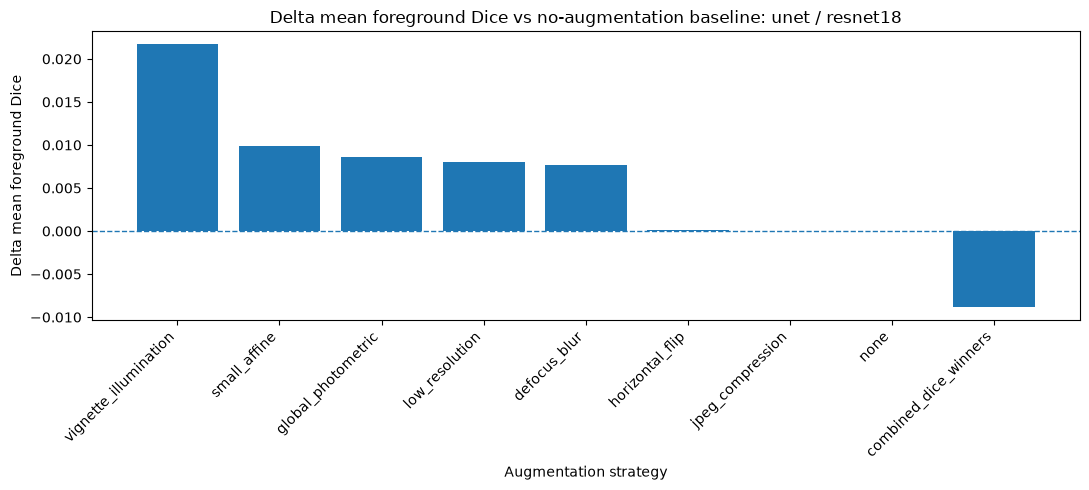

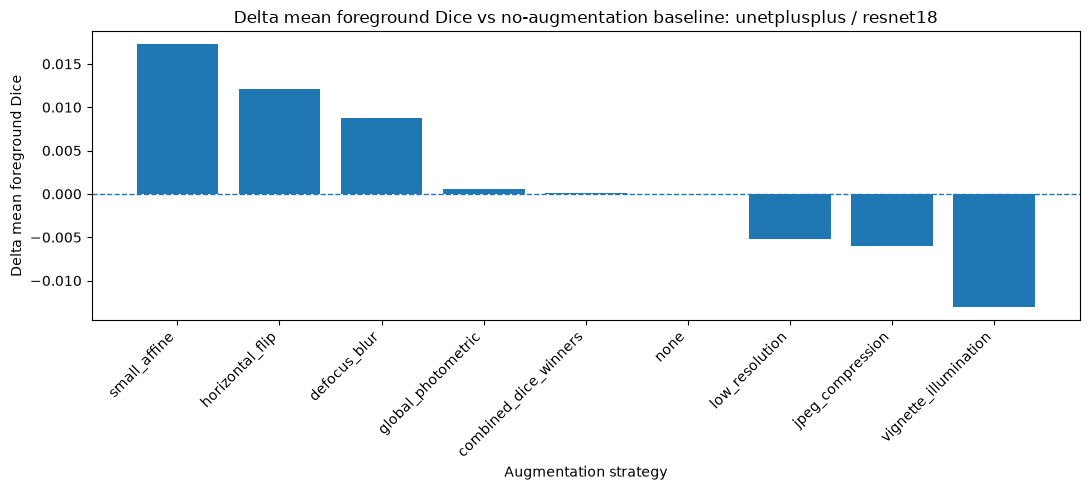

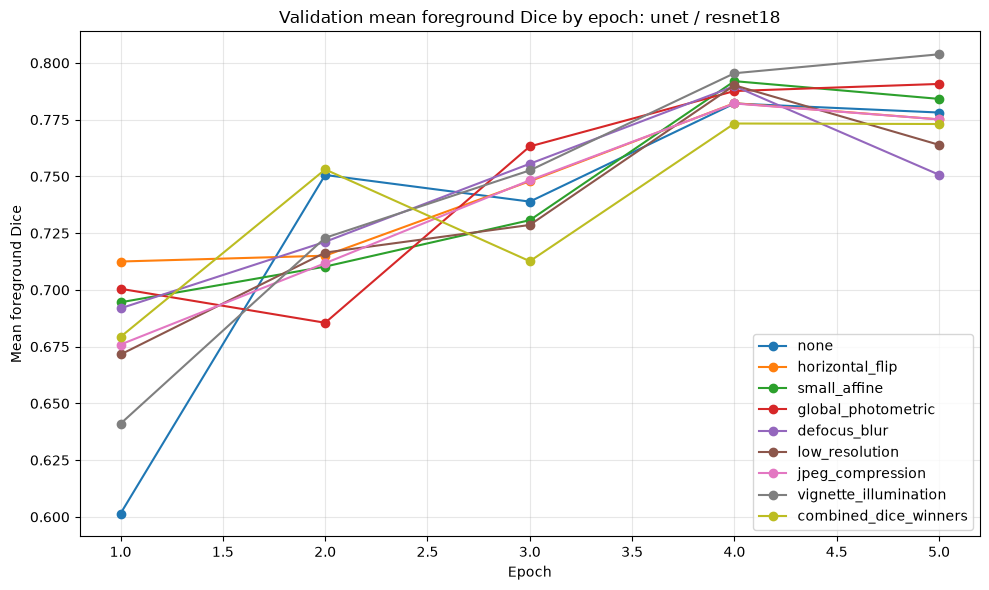

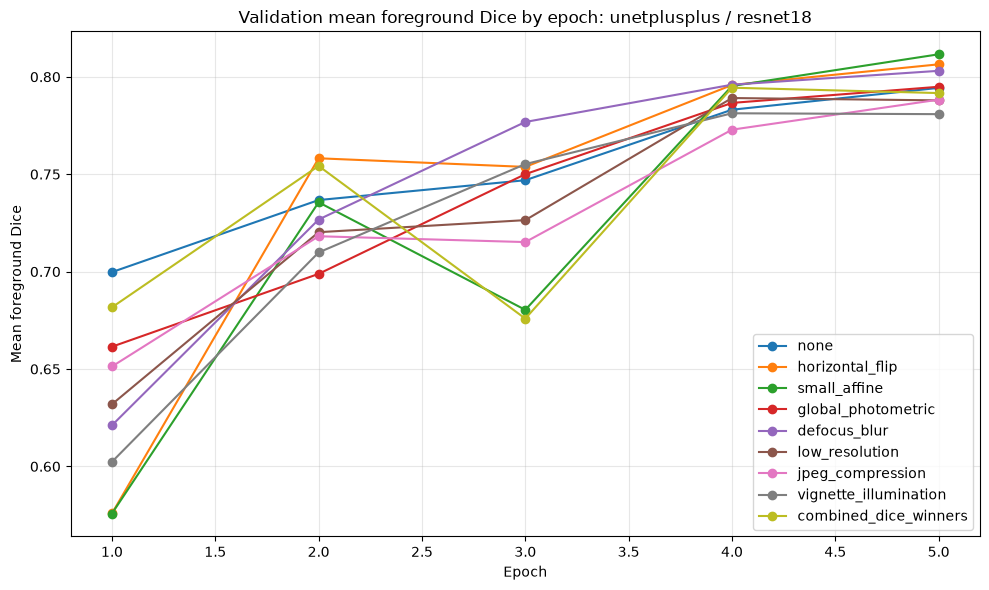

In [34]:
# 05.34 — Plot Dice-first augmentation screen results

plot_summary = screen_summary.copy()

for (model_name, encoder_name), group in plot_summary.groupby(["model", "encoder"], dropna=False):
    group = group.sort_values("delta_mean_foreground_dice_vs_model_baseline", ascending=False)

    plt.figure(figsize=(11, 5))
    plt.bar(group["augmentation_strategy"], group["delta_mean_foreground_dice_vs_model_baseline"])
    plt.axhline(0.0, linestyle="--", linewidth=1)
    plt.title(f"Delta mean foreground Dice vs no-augmentation baseline: {model_name} / {encoder_name}")
    plt.xlabel("Augmentation strategy")
    plt.ylabel("Delta mean foreground Dice")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

independent_history = _read_csv_or_empty(INDEPENDENT_HISTORY_PATH)
combined_history = _read_csv_or_empty(COMBINED_HISTORY_PATH)

val_history_for_plot = independent_history[independent_history["phase"] == "val"].copy()

if not combined_history.empty:
    combined_val_history = combined_history[combined_history["phase"] == "val"].copy()
    val_history_for_plot = pd.concat([val_history_for_plot, combined_val_history], ignore_index=True, sort=False)

baseline_plot_history = no_aug_val_history.copy()
baseline_plot_history = baseline_plot_history[
    baseline_plot_history[["model", "encoder"]]
    .apply(tuple, axis=1)
    .isin(selected_model_baselines[["model", "encoder"]].apply(tuple, axis=1))
].copy()
baseline_plot_history["augmentation_strategy"] = "none"
baseline_plot_history["mean_foreground_dice"] = (
    baseline_plot_history["disc_dice"] + baseline_plot_history["cup_dice"]
) / 2.0

curve_history = pd.concat(
    [
        baseline_plot_history[
            ["model", "encoder", "augmentation_strategy", "epoch", "mean_foreground_dice", "disc_dice", "cup_dice", "cdr_mae", "loss"]
        ],
        val_history_for_plot[
            ["model", "encoder", "augmentation_strategy", "epoch", "mean_foreground_dice", "disc_dice", "cup_dice", "cdr_mae", "loss"]
        ],
    ],
    ignore_index=True,
    sort=False,
)

for (model_name, encoder_name), group in curve_history.groupby(["model", "encoder"], dropna=False):
    plt.figure(figsize=(10, 6))

    for strategy_name, strategy_group in group.groupby("augmentation_strategy", sort=False):
        strategy_group = strategy_group.sort_values("epoch")
        plt.plot(
            strategy_group["epoch"],
            strategy_group["mean_foreground_dice"],
            marker="o",
            label=strategy_name,
        )

    plt.title(f"Validation mean foreground Dice by epoch: {model_name} / {encoder_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Mean foreground Dice")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 05.35 — Final Notebook 05 handoff summary

In [35]:
# 05.35 — Final Notebook 05 handoff summary

best_rows = (
    screen_summary.sort_values(
        ["model", "best_val_mean_foreground_dice"],
        ascending=[True, False],
    )
    .groupby(["model", "encoder"], dropna=False)
    .head(1)
    .reset_index(drop=True)
)

dice_winner_rows = screen_summary[
    (screen_summary["result_type"].isin(["independent_online_augmentation", "combined_online_winner_policy"]))
    & (screen_summary["improves_primary_mean_foreground_dice"])
].copy()

handoff_summary = pd.DataFrame(
    [
        {
            "item": "primary metric",
            "status": "COMPLETE",
            "detail": "Mean foreground Dice = average of disc Dice and cup Dice.",
        },
        {
            "item": "selected neural nets",
            "status": "COMPLETE",
            "detail": "; ".join(
                f"{row['model']} / {row['encoder']}"
                for _, row in selected_model_baselines.iterrows()
            ),
        },
        {
            "item": "atomic strategies screened",
            "status": "COMPLETE",
            "detail": ", ".join(SCREEN_STRATEGIES),
        },
        {
            "item": "dataset size",
            "status": "COMPLETE",
            "detail": "Online augmentation only; no synthetic add-back in Notebook 05.",
        },
        {
            "item": "Dice-improving strategies",
            "status": "RESULT",
            "detail": (
                ", ".join(
                    f"{row['model']}/{row['augmentation_strategy']}"
                    for _, row in dice_winner_rows.iterrows()
                )
                if not dice_winner_rows.empty
                else "None improved mean foreground Dice in this screen."
            ),
        },
        {
            "item": "best result per selected neural net",
            "status": "RESULT",
            "detail": "; ".join(
                f"{row['model']} / {row['encoder']}: {row['augmentation_strategy']} "
                f"({row['best_val_mean_foreground_dice']:.4f})"
                for _, row in best_rows.iterrows()
            ),
        },
        {
            "item": "Notebook 06 handoff",
            "status": "READY",
            "detail": "Use Dice-improving strategies for synthetic data expansion with original + augmented add-back manifests.",
        },
    ]
)

display(handoff_summary)

display(
    screen_summary[screen_display_columns]
    .sort_values(["model", "best_val_mean_foreground_dice"], ascending=[True, False])
    .reset_index(drop=True)
)

,item,status,detail
0,primary metric,COMPLETE,Mean foreground Dice = average of disc Dice an...
1,selected neural nets,COMPLETE,unetplusplus / resnet18; unet / resnet18
2,atomic strategies screened,COMPLETE,"horizontal_flip, small_affine, global_photomet..."
3,dataset size,COMPLETE,Online augmentation only; no synthetic add-bac...
4,Dice-improving strategies,RESULT,"unetplusplus/horizontal_flip, unetplusplus/sma..."
5,best result per selected neural net,RESULT,unet / resnet18: vignette_illumination (0.8038...
6,Notebook 06 handoff,READY,Use Dice-improving strategies for synthetic da...


,result_type,model,encoder,augmentation_strategy,best_epoch_by_mean_foreground_dice,best_val_mean_foreground_dice,delta_mean_foreground_dice_vs_model_baseline,best_val_disc_dice,delta_disc_dice_vs_model_baseline,best_val_cup_dice,delta_cup_dice_vs_model_baseline,best_val_cdr_mae,delta_cdr_mae_vs_model_baseline,best_val_loss_at_best_dice,delta_val_loss_vs_model_baseline,improves_primary_mean_foreground_dice
0,independent_online_augmentation,unet,resnet18,vignette_illumination,5,0.803803,0.021678,0.829354,0.019648,0.778252,0.023707,0.072379,-0.005164,0.160496,-0.022187,True
1,independent_online_augmentation,unet,resnet18,small_affine,4,0.791973,0.009847,0.813688,0.003982,0.770258,0.015713,0.076462,-0.001081,0.181572,-0.001110,True
2,independent_online_augmentation,unet,resnet18,global_photometric,5,0.790742,0.008616,0.817731,0.008024,0.763752,0.009207,0.073748,-0.003795,0.164209,-0.018474,True
3,independent_online_augmentation,unet,resnet18,low_resolution,4,0.790148,0.008023,0.811736,0.002030,0.768561,0.014016,0.070581,-0.006961,0.179451,-0.003232,True
4,independent_online_augmentation,unet,resnet18,defocus_blur,4,0.789795,0.007670,0.820003,0.010297,0.759587,0.005042,0.073568,-0.003974,0.178173,-0.004510,True
5,independent_online_augmentation,unet,resnet18,horizontal_flip,4,0.782265,0.000139,0.804990,-0.004716,0.759540,0.004995,0.075755,-0.001788,0.185083,0.002401,False
6,independent_online_augmentation,unet,resnet18,jpeg_compression,4,0.782144,0.000018,0.803840,-0.005866,0.760447,0.005902,0.073499,-0.004044,0.187579,0.004897,False
7,no_augmentation_model_baseline,unet,resnet18,none,4,0.782126,0.000000,0.809706,0.000000,0.754545,0.000000,0.077542,0.000000,0.182682,0.000000,False
8,combined_online_winner_policy,unet,resnet18,combined_dice_winners,4,0.773312,-0.008814,0.797350,-0.012356,0.749273,-0.005272,0.083554,0.006011,0.196790,0.014108,False
9,independent_online_augmentation,unetplusplus,resnet18,small_affine,5,0.811561,0.017243,0.841416,0.021529,0.781706,0.012957,0.068719,-0.017643,0.167172,-0.010957,True
